# STTC High-Activity Coactivity Network

Build lightweight weighted STTC functional coactivity networks from spike/MUA events restricted to **high-activity non-burst** periods. The analysis follows the Cutts-Eglen spike time tiling coefficient used in the Akarca/Dunn eLife functional-connectivity workflow, but intentionally avoids default all-pair surrogate inference.

Default output is a weighted adjacency matrix plus thresholded edge views for graph exploration.

In [33]:
%matplotlib inline
import hashlib
import json
import pickle
import sys
import time
from pathlib import Path
from types import SimpleNamespace

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "ephax").exists() and (repo_root.parent / "ephax").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from ephax import PrepConfig, RestingActivityDataset
from ephax.metrics import (
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    compute_sttc_adjacency,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
    normalize_interval_array,
    read_sttc_network_cache,
    spike_times_by_electrode_in_intervals,
    sttc_spike_proportion,
    sttc_tiling_proportion,
    thresholded_edge_table,
    write_sttc_network_cache,
)

In [34]:
# Dataset / scope. Keep names aligned with burst_analysis.ipynb and activity_distance_spike.ipynb.
DATASET = "stim_removal_null"  # "stim_removal_null" or "raw_h5"
# Scope booleans. These define the requested matrix directly:
#   False/False: one cell = WELL x DIV
#   True/False:  one DIV column = all AGGREGATE_WELLS x DIV
#   False/True:  one well row = WELL x all AGGREGATE_DIVS
#   True/True:   full matrix = all AGGREGATE_WELLS x all AGGREGATE_DIVS
RUN_ALL_WELLS = True
RUN_ALL_DIVS = True
WELL = 3
DIV = 21
DIVS = [12, 14, 21, 22, 23, 26]
AGGREGATE_WELLS = [0, 1, 2, 3, 4, 5]
AGGREGATE_DIVS = DIVS

# Derived label for cache summaries and plot titles only. Compute logic uses RUN_ALL_WELLS/RUN_ALL_DIVS.
if RUN_ALL_WELLS and RUN_ALL_DIVS:
    RUN_MODE = "all_wells_all_divs"
elif RUN_ALL_WELLS:
    RUN_MODE = "all_wells_single_div"
elif RUN_ALL_DIVS:
    RUN_MODE = "single_well_all_divs"
else:
    RUN_MODE = "single_recording"

START_SEC = 0.0
END_SEC = 600.0
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

# State detection, copied from the burst-analysis defaults.
IFR_GRID_HZ = 50.0
SMOOTH_SIGMA_SEC = 0.15
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0
NETWORK_MAX_GAP_BINS = 0

# STTC network settings.
STTC_DT_MS = 2.0
STTC_DT_SENSITIVITY_MS = [2.0, 5.0, 10.0]
STTC_MIN_RATE_HZ = 0.01
STTC_MAX_ELECTRODES = 1000  # set None for all selected electrodes
STTC_KEEP_NEGATIVE = False
STTC_TOP_EDGE_FRACTIONS = [0.01, 0.05, 0.10]
STTC_ABS_THRESHOLD = None
STTC_NULL_REPS = 1
STTC_NULL_RESIDUAL_FORCE_RECOMPUTE = False
STTC_NULL_PAIR_SAMPLE_PER_RECORDING = 3000
STTC_NULL_PAIR_DISTANCE_BIN_UM = 200.0
STTC_NULL_PAIR_STRATIFY_BY_DISTANCE = True
STTC_DISTANCE_CURVE_BIN_UM = 100.0
STTC_DISTANCE_CURVE_MAX_UM = 3500.0
STTC_DISTANCE_CI_BOOTSTRAP_REPS = 500
STTC_DISTANCE_CI_RANDOM_SEED = 0
STTC_RANDOM_SEED = 0
STTC_FORCE_RECOMPUTE = False
STTC_STATE_FORCE_RECOMPUTE = False

STTC_ACTIVITY_SCOPE = "high_activity_non_burst" # "high_activity_non_burst" or "high_activity" or "burst"
OUTPUT_DIR = repo_root / "outputs" / "sttc_networks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STIM_DATA_ROOT = repo_root / "ephax" / "data" / "stimRemovalNull"
RAW_H5_DIV = 40
H5_FILE_INFO = [
    ("/Users/danielrebbin/Documents/Academia/UvA/Internship/Wes_Files/Data/Stimulation/2407/ephaptic_stimulation_caspfiguration_control_2.raw.h5", well, div)
    for well in AGGREGATE_WELLS
    for div in [RAW_H5_DIV]
]

## Loading and State Helpers

The analysis state is defined as high-activity intervals after subtracting participation-defined bursts. Spike times are then restricted to these intervals and concatenated in interval-relative time, so removed gaps do not contribute to STTC tiled recording time.

In [35]:
def stim_recording_path(well: int, div: int) -> Path:
    # Match Figure 2 / burst_analysis: files live under stimRemovalNull/well{well}/...
    return STIM_DATA_ROOT / f"well{int(well)}" / f"DIV{int(div)}_240703_data_well{int(well)}_exp_data.npz"


def build_recording_spec(well: int, div: int) -> dict:
    if DATASET == "stim_removal_null":
        path = stim_recording_path(well, div)
        return {
            "dataset": DATASET,
            "well": int(well),
            "div": int(div),
            "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
            "source_file": path,
            "source": "npz",
            "base_dir": None,
        }
    if DATASET == "raw_h5":
        # Processed H5 loader expects (folder, filename, start, end, well).
        if isinstance(H5_FILE_INFO, dict):
            if int(well) not in H5_FILE_INFO:
                raise ValueError(f"No raw_h5 file info configured for well {well}.")
            folder, filename, source_well = H5_FILE_INFO[int(well)]
            path = Path(folder) / filename
        else:
            matches = [item for item in H5_FILE_INFO if int(item[1]) == int(well)]
            if not matches:
                raise ValueError(f"No raw_h5 file info configured for well {well}.")
            raw_path, source_well, _ = matches[0]
            raw_path = Path(raw_path)
            folder, filename = str(raw_path.parent), raw_path.name
            path = raw_path
        return {
            "dataset": DATASET,
            "well": int(well),
            "div": int(RAW_H5_DIV),
            "recording_id": f"raw_h5_well{int(well)}_DIV{int(RAW_H5_DIV)}",
            "source_file": path,
            "source": "h5",
            "base_dir": None,
            "h5_folder": folder,
            "h5_filename": filename,
            "h5_well": int(source_well),
        }
    raise ValueError(f"Unsupported DATASET={DATASET!r}")


def requested_wells() -> list[int]:
    return [int(w) for w in (AGGREGATE_WELLS if RUN_ALL_WELLS else [WELL])]


def requested_divs() -> list[int]:
    return [int(d) for d in (AGGREGATE_DIVS if RUN_ALL_DIVS else [DIV])]


def iter_recording_specs() -> list[dict]:
    return [build_recording_spec(well, div) for div in requested_divs() for well in requested_wells()]


def rebase_dataset_clock(ds):
    # Figure 2 uses a zero-based analysis clock after loading the requested recording window.
    for rec in ds.recordings:
        offset_s = float(rec.start_time)
        rec.spikes = {**rec.spikes, "time": np.asarray(rec.spikes["time"], dtype=float) - offset_s}
        rec.end_time = float(rec.end_time) - offset_s
        rec.start_time = 0.0
    return ds


def load_recording_from_spec(spec: dict):
    start_sec = float(START_SEC)
    end_sec = float(END_SEC) if END_SEC is not None else None
    if spec["source"] == "npz":
        path = Path(spec["source_file"])
        if not path.exists():
            raise FileNotFoundError(f"Missing stimRemovalNull file: {path}")
        with np.load(path, allow_pickle=True) as data:
            sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
            frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
            rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
        load_end = rec_t0 + end_sec if end_sec is not None else rec_t0 + 600.0
        file_info = [(str(path), rec_t0 + start_sec, load_end, int(spec["well"]))]
        ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=MIN_AMP)
    elif spec["source"] == "h5":
        load_end = end_sec if end_sec is not None else 600.0
        file_info = [(spec["h5_folder"], spec["h5_filename"], start_sec, load_end, int(spec["h5_well"]))]
        ds = RestingActivityDataset.from_file_info(file_info, source="h5", min_amp=MIN_AMP, base_dir=spec.get("base_dir"))
    else:
        raise ValueError(f"Unsupported source={spec['source']!r}")
    if not ds.recordings:
        raise ValueError(f"No recordings loaded for {spec['recording_id']}.")
    ds = rebase_dataset_clock(ds)
    return ds, ds.recordings[0]


def normalize_intervals_df(intervals) -> pd.DataFrame:
    arr = normalize_interval_array(intervals)
    if arr.size == 0:
        return pd.DataFrame(columns=["start_time_s", "end_time_s", "duration_s"])
    return pd.DataFrame({
        "start_time_s": arr[:, 0],
        "end_time_s": arr[:, 1],
        "duration_s": arr[:, 1] - arr[:, 0],
    })


def subtract_intervals(base, remove) -> pd.DataFrame:
    base_arr = normalize_interval_array(base)
    remove_arr = normalize_interval_array(remove)
    pieces = []
    for start, end in base_arr:
        current = [(float(start), float(end))]
        for r_start, r_end in remove_arr:
            next_current = []
            for c_start, c_end in current:
                if r_end <= c_start or r_start >= c_end:
                    next_current.append((c_start, c_end))
                    continue
                if r_start > c_start:
                    next_current.append((c_start, min(c_end, r_start)))
                if r_end < c_end:
                    next_current.append((max(c_start, r_end), c_end))
            current = next_current
            if not current:
                break
        pieces.extend(current)
    return normalize_intervals_df(pieces)


def coords_for_electrodes(recording, electrodes) -> np.ndarray:
    layout = pd.DataFrame(recording.layout)
    layout = layout.drop_duplicates("electrode").set_index("electrode")
    coords = layout.reindex(np.asarray(electrodes, dtype=int))[ ["x", "y"] ].to_numpy(dtype=float)
    return coords


In [36]:
ACTIVITY_STATE_CACHE_CONTENT = {
    "refs": "selected_electrodes_int32",
    "population": ["time_grid", "mean_ifr", "mean_ifr_smooth"],
    "interval_tables": ["high_epochs", "burst_epochs", "selected_intervals"],
}


def activity_state_cache_config(spec: dict) -> dict:
    return {
        "recording_id": spec["recording_id"],
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "start_sec": START_SEC,
        "end_sec": END_SEC,
        "min_amp": MIN_AMP,
        "top_start": TOP_START,
        "top_stop": TOP_STOP,
        "ifr_grid_hz": IFR_GRID_HZ,
        "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
        "high_activity_mad_scale": HIGH_ACTIVITY_MAD_SCALE,
        "high_activity_min_duration_ms": HIGH_ACTIVITY_MIN_DURATION_MS,
        "high_activity_max_gap_bins": HIGH_ACTIVITY_MAX_GAP_BINS,
        "highres_bin_ms": HIGHRES_BIN_MS,
        "highres_smooth_sigma_ms": HIGHRES_SMOOTH_SIGMA_MS,
        "network_bin_ms": NETWORK_BIN_MS,
        "network_min_participation_fraction": NETWORK_MIN_PARTICIPATION_FRACTION,
        "network_min_duration_ms": NETWORK_MIN_DURATION_MS,
        "network_max_gap_bins": NETWORK_MAX_GAP_BINS,
        "cache_content": ACTIVITY_STATE_CACHE_CONTENT,
    }


def activity_state_cache_path(spec: dict) -> Path:
    config = activity_state_cache_config(spec)
    digest = hashlib.sha1(json.dumps(config, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    return OUTPUT_DIR / f"activity_state_{spec['recording_id']}_{digest}.pkl"


def compact_population_ifr(population) -> dict:
    return {
        "time_grid": np.asarray(population.time_grid, dtype=np.float32),
        "mean_ifr": np.asarray(population.mean_ifr, dtype=np.float32),
        "mean_ifr_smooth": np.asarray(population.mean_ifr_smooth, dtype=np.float32),
    }


def restore_population_ifr(population):
    if not isinstance(population, dict):
        return population
    required = {"time_grid", "mean_ifr", "mean_ifr_smooth"}
    missing = required.difference(population)
    if missing:
        raise ValueError(f"Activity-state cache population is missing fields: {sorted(missing)}")
    return SimpleNamespace(
        time_grid=np.asarray(population["time_grid"], dtype=float),
        mean_ifr=np.asarray(population["mean_ifr"], dtype=float),
        mean_ifr_smooth=np.asarray(population["mean_ifr_smooth"], dtype=float),
    )


def load_activity_state_cache(spec: dict):
    path = activity_state_cache_path(spec)
    if not path.exists() or STTC_STATE_FORCE_RECOMPUTE:
        return None
    with path.open("rb") as f:
        cached = pickle.load(f)
    if cached.get("cache_config") != activity_state_cache_config(spec):
        return None
    cached["population"] = restore_population_ifr(cached.get("population"))
    cached["summary"] = {**cached["summary"], "state_cache_source": "cache", "state_cache_path": str(path)}
    return cached


def write_activity_state_cache(spec: dict, payload: dict):
    path = activity_state_cache_path(spec)
    cache_payload = {
        "cache_config": activity_state_cache_config(spec),
        "refs": np.asarray(payload["refs"], dtype=np.int32),
        "population": compact_population_ifr(payload["population"]),
        "high_epochs": payload["high_epochs"],
        "burst_epochs": payload["burst_epochs"],
        "selected_intervals": payload["selected_intervals"],
        "summary": {**payload["summary"], "state_cache_source": "computed", "state_cache_path": str(path)},
    }
    with path.open("wb") as f:
        pickle.dump(cache_payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def detect_recording_activity(spec: dict) -> dict:
    t0 = time.perf_counter()
    try:
        ds, rec = load_recording_from_spec(spec)
        cached = load_activity_state_cache(spec)
        if cached is not None:
            summary = {
                **cached["summary"],
                "start_sec": float(rec.start_time),
                "end_sec": float(rec.end_time),
                "n_spikes": int(len(rec.spikes["time"])),
                "n_active_electrodes": int(np.unique(rec.spikes["electrode"]).size),
                "elapsed_s": time.perf_counter() - t0,
            }
            return {
                "spec": spec,
                "dataset_obj": ds,
                "recording": rec,
                "refs": np.asarray(cached["refs"], dtype=int),
                "population": cached["population"],
                "high_epochs": cached["high_epochs"],
                "burst_epochs": cached["burst_epochs"],
                "selected_intervals": cached["selected_intervals"],
                "summary": summary,
            }

        prep_cfg = PrepConfig(
            min_amp=MIN_AMP,
            mode="top",
            top_start=TOP_START,
            top_stop=TOP_STOP,
            top_use_recording_window=True,
            verbose=False,
        )
        refs = ds.select_ref_electrodes(prep_cfg)[0]
        if refs.size == 0:
            raise ValueError("No reference electrodes selected.")

        population = build_population_ifr(
            rec,
            refs,
            grid_hz=IFR_GRID_HZ,
            smooth_sigma_sec=SMOOTH_SIGMA_SEC,
        )
        high_epochs, high_info = detect_high_activity_epochs(
            population.time_grid,
            population.mean_ifr_smooth,
            mad_scale=HIGH_ACTIVITY_MAD_SCALE,
            min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
            max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
        )
        highres = build_highres_traces(
            rec,
            refs,
            bin_ms=HIGHRES_BIN_MS,
            smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
        )
        activity = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
        burst_epochs = detect_participation_burst_epochs(
            activity,
            high_epochs,
            min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
            min_duration_ms=NETWORK_MIN_DURATION_MS,
            max_gap_bins=NETWORK_MAX_GAP_BINS,
        )
        selected_intervals = subtract_intervals(high_epochs, burst_epochs)
        selected_intervals = selected_intervals[selected_intervals["duration_s"] > 0].reset_index(drop=True)
        selected_intervals["event_idx"] = np.arange(len(selected_intervals), dtype=int)

        summary = {
            **{k: spec[k] for k in ["dataset", "well", "div", "recording_id", "source_file"]},
            "valid_for_sttc": len(selected_intervals) > 0,
            "skip_reason": "" if len(selected_intervals) > 0 else "no_high_activity_non_burst_intervals",
            "start_sec": float(rec.start_time),
            "end_sec": float(rec.end_time),
            "n_spikes": int(len(rec.spikes["time"])),
            "n_active_electrodes": int(np.unique(rec.spikes["electrode"]).size),
            "n_refs": int(refs.size),
            "n_high_activity_periods": int(len(high_epochs)),
            "n_burst_periods": int(len(burst_epochs)),
            "n_selected_periods": int(len(selected_intervals)),
            "selected_duration_s": float(selected_intervals["duration_s"].sum()) if len(selected_intervals) else 0.0,
            "high_activity_threshold_hz": float(high_info.get("threshold_hz", np.nan)),
            "state_cache_source": "computed",
            "state_cache_path": str(activity_state_cache_path(spec)),
            "elapsed_s": time.perf_counter() - t0,
        }
        payload = {
            "spec": spec,
            "dataset_obj": ds,
            "recording": rec,
            "refs": refs,
            "population": population,
            "high_epochs": high_epochs,
            "burst_epochs": burst_epochs,
            "selected_intervals": selected_intervals,
            "summary": summary,
        }
        write_activity_state_cache(spec, payload)
        return payload
    except Exception as exc:
        return {
            "spec": spec,
            "dataset_obj": None,
            "recording": None,
            "refs": np.array([], dtype=int),
            "population": None,
            "high_epochs": pd.DataFrame(),
            "burst_epochs": pd.DataFrame(),
            "selected_intervals": pd.DataFrame(),
            "summary": {
                **{k: spec[k] for k in ["dataset", "well", "div", "recording_id", "source_file"]},
                "valid_for_sttc": False,
                "skip_reason": str(exc),
                "start_sec": np.nan,
                "end_sec": np.nan,
                "n_spikes": 0,
                "n_active_electrodes": 0,
                "n_refs": 0,
                "n_high_activity_periods": 0,
                "n_burst_periods": 0,
                "n_selected_periods": 0,
                "selected_duration_s": 0.0,
                "high_activity_threshold_hz": np.nan,
                "elapsed_s": time.perf_counter() - t0,
            },
        }


recording_specs = iter_recording_specs()
activity_results = [detect_recording_activity(spec) for spec in recording_specs]
recording_summary = pd.DataFrame([item["summary"] for item in activity_results])
recording_summary

,dataset,well,div,recording_id,source_file,valid_for_sttc,skip_reason,start_sec,end_sec,n_spikes,n_active_electrodes,n_refs,n_high_activity_periods,n_burst_periods,n_selected_periods,selected_duration_s,high_activity_threshold_hz,state_cache_source,state_cache_path,elapsed_s
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,252494,1005,1000,27,141,168,131.24,0.182375,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.331085
1,stim_removal_null,1,12,stimRemovalNull_well1_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,209064,1008,1000,21,129,150,111.44,0.124123,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.158458
2,stim_removal_null,2,12,stimRemovalNull_well2_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,230117,997,997,29,85,114,151.88,0.188897,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.179927
3,stim_removal_null,3,12,stimRemovalNull_well3_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,216867,1006,1000,23,124,147,100.26,0.200284,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.160445
4,stim_removal_null,4,12,stimRemovalNull_well4_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,187888,989,989,30,110,140,115.89,0.147510,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.142284
5,stim_removal_null,5,12,stimRemovalNull_well5_DIV12,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,213439,1005,1000,31,129,160,95.42,0.147966,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.226506
6,stim_removal_null,0,14,stimRemovalNull_well0_DIV14,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,263329,1011,1000,26,122,148,149.65,0.214701,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.241517
7,stim_removal_null,1,14,stimRemovalNull_well1_DIV14,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,250873,1011,1000,24,130,154,142.36,0.268017,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.338498
8,stim_removal_null,2,14,stimRemovalNull_well2_DIV14,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,214145,1009,1000,28,90,118,152.27,0.211576,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.752759
9,stim_removal_null,3,14,stimRemovalNull_well3_DIV14,/Users/danielrebbin/Documents/GitHub/ephax/eph...,True,,0.0,600.0,281360,1004,1000,22,160,182,176.84,0.209534,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,0.217425


In [37]:
interval_rows = []
for item in activity_results:
    for kind, table in [
        ("high_activity", item["high_epochs"]),
        ("burst", item["burst_epochs"]),
        ("high_activity_non_burst", item["selected_intervals"]),
    ]:
        if table is None or len(table) == 0:
            continue
        for row in table.itertuples(index=False):
            start = float(getattr(row, "start_time_s"))
            end = float(getattr(row, "end_time_s"))
            interval_rows.append({
                "dataset": item["spec"]["dataset"],
                "well": item["spec"]["well"],
                "div": item["spec"]["div"],
                "recording_id": item["spec"]["recording_id"],
                "interval_kind": kind,
                "start_time_s": start,
                "end_time_s": end,
                "duration_s": end - start,
            })
interval_summary = pd.DataFrame(interval_rows)
interval_summary.head()

,dataset,well,div,recording_id,interval_kind,start_time_s,end_time_s,duration_s
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,15.88,21.78,5.90
1,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,40.04,45.14,5.10
2,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,61.56,66.62,5.06
3,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,81.36,87.36,6.00
4,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,high_activity,104.26,109.40,5.14


## State QC

The selected intervals are the orange spans: high-activity periods with participation-burst epochs removed.

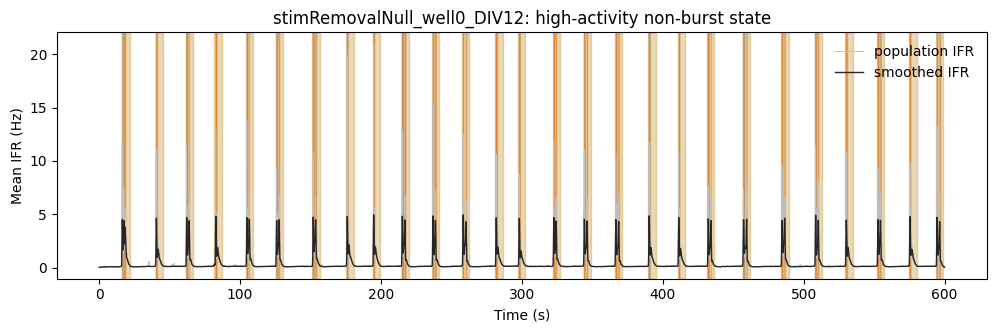

In [38]:
def draw_state_qc(item):
    if item["population"] is None:
        raise ValueError("No population IFR available for this recording.")
    pop = item["population"]
    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.plot(pop.time_grid, pop.mean_ifr, color="0.75", lw=0.7, label="population IFR")
    ax.plot(pop.time_grid, pop.mean_ifr_smooth, color="0.15", lw=1.0, label="smoothed IFR")
    for row in item["high_epochs"].itertuples(index=False):
        ax.axvspan(float(row.start_time_s), float(row.end_time_s), color="tab:green", alpha=0.12)
    for row in item["burst_epochs"].itertuples(index=False):
        ax.axvspan(float(row.start_time_s), float(row.end_time_s), color="tab:blue", alpha=0.16)
    for row in item["selected_intervals"].itertuples(index=False):
        ax.axvspan(float(row.start_time_s), float(row.end_time_s), color="tab:orange", alpha=0.22)
    ax.set_title(f"{item['spec']['recording_id']}: high-activity non-burst state")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mean IFR (Hz)")
    ax.legend(loc="upper right", frameon=False)
    return fig, ax

valid_activity_items = [item for item in activity_results if item["summary"]["valid_for_sttc"]]
if valid_activity_items:
    draw_state_qc(valid_activity_items[0]);
else:
    print("No valid high-activity non-burst intervals were found.")

## Compute or Load STTC Networks

The STTC matrix is cached per recording. Re-running plotting cells will not recompute the pairwise matrix unless `STTC_FORCE_RECOMPUTE=True` or the cache path changes through configuration.

In [39]:
def config_digest_for_item(item, electrodes, dt_ms=None) -> str:
    dt_ms = float(STTC_DT_MS if dt_ms is None else dt_ms)
    payload = {
        "dataset": item["spec"]["dataset"],
        "recording_id": item["spec"]["recording_id"],
        "start_sec": item["summary"].get("start_sec"),
        "end_sec": item["summary"].get("end_sec"),
        "activity_scope": STTC_ACTIVITY_SCOPE,
        "dt_ms": dt_ms,
        "min_rate_hz": STTC_MIN_RATE_HZ,
        "max_electrodes": STTC_MAX_ELECTRODES,
        "keep_negative": STTC_KEEP_NEGATIVE,
        "top_start": TOP_START,
        "top_stop": TOP_STOP,
        "electrodes": list(map(int, np.asarray(electrodes, dtype=int))),
        "intervals": np.round(item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float), 6).tolist(),
    }
    return hashlib.sha1(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:12]


def sttc_cache_path(item, digest: str, dt_ms=None) -> Path:
    spec = item["spec"]
    dt_ms = float(STTC_DT_MS if dt_ms is None else dt_ms)
    max_label = "all" if STTC_MAX_ELECTRODES is None else str(int(STTC_MAX_ELECTRODES))
    dt_label = f"{dt_ms:g}".replace(".", "p")
    return OUTPUT_DIR / f"sttc_{spec['recording_id']}_{STTC_ACTIVITY_SCOPE}_dt{dt_label}ms_max{max_label}_{digest}.h5"


def select_sttc_electrodes(item) -> np.ndarray:
    refs = np.asarray(item["refs"], dtype=int)
    if STTC_MAX_ELECTRODES is None or refs.size <= int(STTC_MAX_ELECTRODES):
        return refs
    # Refs from PrepConfig(mode='top') are already activity sorted. Keep the most active cap deterministically.
    return refs[: int(STTC_MAX_ELECTRODES)]


def compute_or_load_sttc_network(item, dt_ms=None):
    dt_ms = float(STTC_DT_MS if dt_ms is None else dt_ms)
    if not item["summary"]["valid_for_sttc"]:
        return None
    rec = item["recording"]
    electrodes_requested = select_sttc_electrodes(item)
    digest = config_digest_for_item(item, electrodes_requested, dt_ms=dt_ms)
    path = sttc_cache_path(item, digest, dt_ms=dt_ms)
    if path.exists() and not STTC_FORCE_RECOMPUTE:
        cached = read_sttc_network_cache(path)
        adjacency = cached["adjacency"]
        electrodes = cached["electrodes"].astype(int)
        coords_um = cached["coords_um"]
        rates_hz = cached["rates_hz"]
        intervals = cached["intervals_s"]
        source = "cache"
    else:
        t0 = time.perf_counter()
        intervals = item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float)
        spikes_by_electrode, retained_duration_s = spike_times_by_electrode_in_intervals(rec, electrodes_requested, intervals)
        result = compute_sttc_adjacency(
            spikes_by_electrode,
            retained_duration_s,
            dt_ms=dt_ms,
            min_rate_hz=STTC_MIN_RATE_HZ,
            keep_negative=STTC_KEEP_NEGATIVE,
        )
        electrodes = result["electrodes"].astype(int)
        adjacency = result["adjacency"]
        rates_hz = result["rates_hz"]
        coords_um = coords_for_electrodes(rec, electrodes)
        config = {
            "dataset": item["spec"]["dataset"],
            "recording_id": item["spec"]["recording_id"],
            "well": int(item["spec"]["well"]),
            "div": int(item["spec"]["div"]),
            "activity_scope": STTC_ACTIVITY_SCOPE,
            "dt_ms": float(dt_ms),
            "min_rate_hz": float(STTC_MIN_RATE_HZ),
            "max_electrodes": -1 if STTC_MAX_ELECTRODES is None else int(STTC_MAX_ELECTRODES),
            "keep_negative": int(bool(STTC_KEEP_NEGATIVE)),
            "top_start": int(TOP_START),
            "top_stop": -1 if TOP_STOP is None else int(TOP_STOP),
            "retained_duration_s": float(retained_duration_s),
            "config_digest": digest,
            "compute_elapsed_s": float(time.perf_counter() - t0),
        }
        write_sttc_network_cache(
            path,
            adjacency=adjacency,
            electrodes=electrodes,
            coords_um=coords_um,
            rates_hz=rates_hz,
            intervals=intervals,
            config=config,
        )
        source = "computed"

    edge_tables = {}
    for fraction in STTC_TOP_EDGE_FRACTIONS:
        edge_tables[float(fraction)] = thresholded_edge_table(
            adjacency,
            electrodes,
            coords=coords_um,
            top_fraction=float(fraction),
        )
    return {
        "item": item,
        "cache_path": path,
        "source": source,
        "adjacency": adjacency,
        "electrodes": electrodes,
        "coords_um": coords_um,
        "rates_hz": rates_hz,
        "intervals_s": intervals,
        "edge_tables": edge_tables,
        "dt_ms": float(dt_ms),
    }


def summarize_sttc_result(result) -> dict:
    adj = np.asarray(result["adjacency"], dtype=float)
    triu = adj[np.triu_indices_from(adj, k=1)] if adj.size else np.array([], dtype=float)
    positive = triu[np.isfinite(triu) & (triu > 0)]
    strength = np.nansum(np.maximum(adj, 0), axis=1) if adj.size else np.array([], dtype=float)
    spec = result["item"]["spec"]
    total_edges = adj.shape[0] * (adj.shape[0] - 1) / 2
    thresholds = {}
    for fraction in STTC_TOP_EDGE_FRACTIONS:
        if positive.size:
            thresholds[f"top_{int(100 * fraction)}pct_threshold"] = float(np.quantile(positive, max(0.0, 1.0 - float(fraction))))
        else:
            thresholds[f"top_{int(100 * fraction)}pct_threshold"] = np.nan
    return {
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "recording_id": spec["recording_id"],
        "cache_source": result["source"],
        "cache_path": str(result["cache_path"]),
        "retained_interval_s": float(np.sum(np.asarray(result["intervals_s"])[:, 1] - np.asarray(result["intervals_s"])[:, 0])),
        "n_intervals": int(len(result["intervals_s"])),
        "n_electrodes": int(adj.shape[0]),
        "n_positive_edges": int(positive.size),
        "positive_edge_density": float(positive.size / total_edges) if total_edges else np.nan,
        "mean_positive_sttc": float(np.mean(positive)) if positive.size else np.nan,
        "median_positive_sttc": float(np.median(positive)) if positive.size else np.nan,
        "mean_node_strength": float(np.mean(strength)) if strength.size else np.nan,
        "median_node_strength": float(np.median(strength)) if strength.size else np.nan,
        **thresholds,
    }


sttc_results = [result for result in (compute_or_load_sttc_network(item) for item in activity_results) if result is not None]
sttc_summary_df = pd.DataFrame([summarize_sttc_result(result) for result in sttc_results])
sttc_summary_df.to_csv(OUTPUT_DIR / "sttc_recording_summary.csv", index=False)
sttc_summary_df

,dataset,well,div,recording_id,cache_source,cache_path,retained_interval_s,n_intervals,n_electrodes,n_positive_edges,positive_edge_density,mean_positive_sttc,median_positive_sttc,mean_node_strength,median_node_strength,top_1pct_threshold,top_5pct_threshold,top_10pct_threshold
0,stim_removal_null,0,12,stimRemovalNull_well0_DIV12,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,131.24,168,924,146649,0.343903,0.027873,0.017418,8.847363,8.398058,0.164685,0.085464,0.062563
1,stim_removal_null,1,12,stimRemovalNull_well1_DIV12,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,111.44,150,947,144626,0.322876,0.030982,0.020683,9.463060,8.720765,0.175603,0.092451,0.066257
2,stim_removal_null,2,12,stimRemovalNull_well2_DIV12,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,151.88,114,912,126705,0.305008,0.030049,0.017140,8.349608,7.642183,0.196007,0.096395,0.069148
3,stim_removal_null,3,12,stimRemovalNull_well3_DIV12,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,100.26,147,914,129306,0.309907,0.031856,0.020498,9.013598,8.489907,0.180709,0.096404,0.068678
4,stim_removal_null,4,12,stimRemovalNull_well4_DIV12,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,115.89,140,915,125809,0.300867,0.030971,0.020396,8.516739,8.004854,0.170673,0.091265,0.066449
5,stim_removal_null,5,12,stimRemovalNull_well5_DIV12,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,95.42,160,960,154758,0.336197,0.030943,0.019909,9.976439,9.142329,0.181196,0.087691,0.063520
6,stim_removal_null,0,14,stimRemovalNull_well0_DIV14,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,149.65,148,944,151085,0.339444,0.028313,0.020018,9.062745,7.771452,0.166102,0.076172,0.056472
7,stim_removal_null,1,14,stimRemovalNull_well1_DIV14,computed,/Users/danielrebbin/Documents/GitHub/ephax/out...,142.36,154,922,139649,0.328910,0.029435,0.020829,8.916784,7.970130,0.167209,0.081477,0.059907
8,stim_removal_null,2,14,stimRemovalNull_well2_DIV14,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,152.27,118,918,135202,0.321219,0.030122,0.021411,8.872697,7.636887,0.168995,0.081064,0.060714
9,stim_removal_null,3,14,stimRemovalNull_well3_DIV14,cache,/Users/danielrebbin/Documents/GitHub/ephax/out...,176.84,182,919,165230,0.391706,0.034794,0.023524,12.511409,11.046061,0.243289,0.100727,0.070630


## Example Network Panels

These panels are descriptive views of the weighted STTC adjacency. Thresholds are visualization thresholds, not pairwise statistical significance tests.

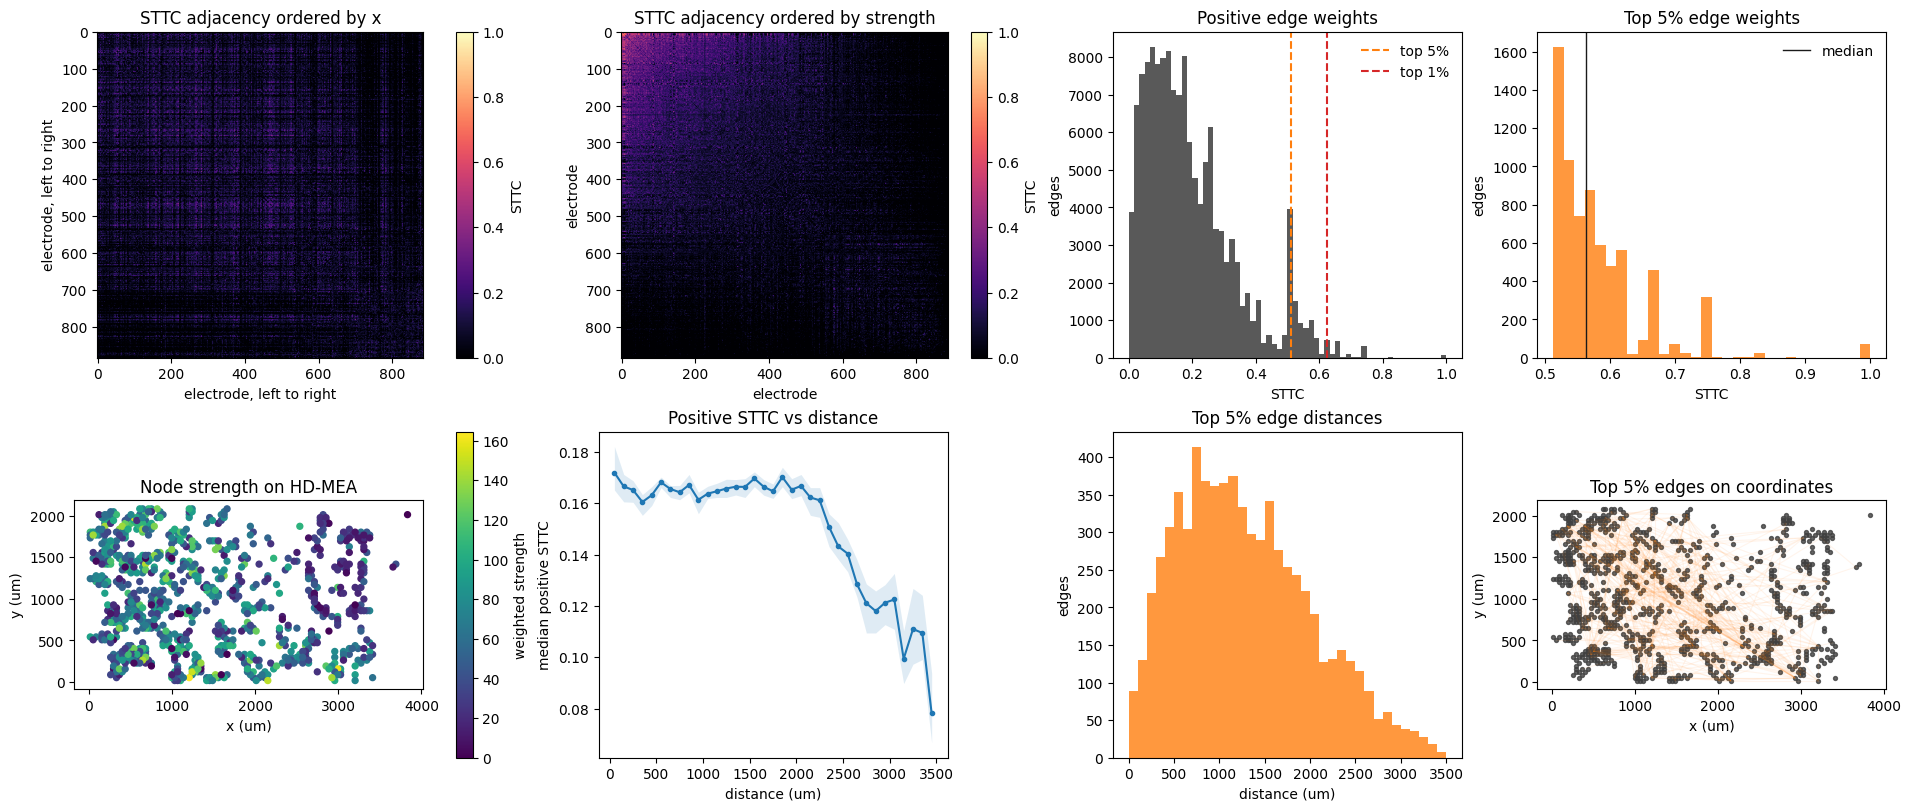

In [40]:
def find_sttc_result(well=None, div=None, fallback_first=True):
    if not sttc_results:
        raise ValueError("No STTC results are available.")
    candidates = sttc_results
    if well is not None:
        candidates = [r for r in candidates if int(r["item"]["spec"]["well"]) == int(well)]
    if div is not None:
        candidates = [r for r in candidates if int(r["item"]["spec"]["div"]) == int(div)]
    if candidates:
        return candidates[0]
    if fallback_first:
        print(f"No STTC result found for well={well}, div={div}; using first computed result instead.")
        return sttc_results[0]
    raise ValueError(f"No STTC result found for well={well}, div={div}.")


def get_example_sttc_result():
    # Flexible default: use the configured WELL/DIV when available, otherwise first computed result.
    # In single_div_all_wells this gives WELL at the selected DIV; in div_progression it gives WELL/DIV.
    return find_sttc_result(well=WELL, div=DIV, fallback_first=True)

def pair_distance_weight_table(result, adjacency=None) -> pd.DataFrame:
    adj = np.asarray(result["adjacency"] if adjacency is None else adjacency, dtype=float)
    coords = np.asarray(result["coords_um"], dtype=float)
    electrodes = np.asarray(result["electrodes"], dtype=int)
    i, j = np.triu_indices(adj.shape[0], k=1)
    weights = adj[i, j]
    delta = coords[i] - coords[j]
    distance_um = np.sqrt(np.sum(delta * delta, axis=1))
    return pd.DataFrame({
        "source_electrode": electrodes[i],
        "target_electrode": electrodes[j],
        "distance_um": distance_um,
        "sttc": weights,
    })


def bootstrap_median_ci(values, n_reps=500, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0 or n_reps <= 0:
        return np.nan, np.nan
    if values.size == 1:
        return float(values[0]), float(values[0])
    rng = np.random.default_rng(seed)
    boot = np.empty(int(n_reps), dtype=float)
    for rep in range(int(n_reps)):
        sample_idx = rng.integers(0, values.size, size=values.size)
        boot[rep] = np.nanmedian(values[sample_idx])
    return float(np.nanquantile(boot, 0.025)), float(np.nanquantile(boot, 0.975))


def binned_sttc_by_distance(
    result,
    bin_um=100,
    max_um=3500,
    adjacency=None,
    ci_bootstrap_reps=0,
    ci_seed=0,
) -> pd.DataFrame:
    pairs = pair_distance_weight_table(result, adjacency=adjacency)
    bins = np.arange(0, max_um + bin_um, bin_um, dtype=float)
    pairs = pairs[(pairs["distance_um"] >= bins[0]) & (pairs["distance_um"] < bins[-1])]
    pairs["distance_bin_um"] = pd.cut(pairs["distance_um"], bins=bins, labels=0.5 * (bins[:-1] + bins[1:]))
    rows = []
    for bin_idx, (center, group) in enumerate(pairs.groupby("distance_bin_um", observed=True)):
        values = group["sttc"].to_numpy(dtype=float)
        positive = values[np.isfinite(values) & (values > 0)]
        ci_low, ci_high = bootstrap_median_ci(
            positive,
            n_reps=int(ci_bootstrap_reps),
            seed=int(ci_seed) + 1009 * int(bin_idx),
        )
        rows.append({
            "distance_um": float(center),
            "n_pairs": int(len(group)),
            "median_sttc": float(np.nanmedian(values)) if values.size else np.nan,
            "mean_sttc": float(np.nanmean(values)) if values.size else np.nan,
            "median_positive_sttc": float(np.nanmedian(positive)) if positive.size else np.nan,
            "positive_fraction": float(np.mean(values > 0)) if values.size else np.nan,
            "ci_low": ci_low,
            "ci_high": ci_high,
        })
    return pd.DataFrame(rows)


def edge_table_from_adjacency(result, adjacency, top_fraction=0.01):
    return thresholded_edge_table(
        adjacency,
        result["electrodes"],
        coords=result["coords_um"],
        top_fraction=float(top_fraction),
    )


def draw_example_network(result, adjacency=None, title_prefix=""):
    adj = np.asarray(result["adjacency"] if adjacency is None else adjacency, dtype=float)
    coords = np.asarray(result["coords_um"], dtype=float)
    strength = np.nansum(np.maximum(adj, 0), axis=1)
    weights = adj[np.triu_indices_from(adj, k=1)]
    positive = weights[np.isfinite(weights) & (weights > 0)]
    top1_threshold = np.quantile(positive, 0.99) if positive.size else np.nan
    top5_threshold = np.quantile(positive, 0.95) if positive.size else np.nan

    # X-only ordering makes left-right spatial structure visible as diagonal bands.
    order_x = np.argsort(coords[:, 0], kind="mergesort")
    order_strength = np.argsort(strength)[::-1]
    distance_summary = binned_sttc_by_distance(
        result,
        adjacency=adj,
        ci_bootstrap_reps=int(globals().get("STTC_DISTANCE_CI_BOOTSTRAP_REPS", 0)),
        ci_seed=int(globals().get("STTC_DISTANCE_CI_RANDOM_SEED", 0)),
    )
    pair_table = pair_distance_weight_table(result, adjacency=adj)
    top5_pairs = pair_table[pair_table["sttc"] >= top5_threshold].copy() if np.isfinite(top5_threshold) else pd.DataFrame()
    top1_pairs = pair_table[pair_table["sttc"] >= top1_threshold].copy() if np.isfinite(top1_threshold) else pd.DataFrame()

    fig, axes = plt.subplots(2, 4, figsize=(19, 8), constrained_layout=True)
    im0 = axes[0, 0].imshow(adj[np.ix_(order_x, order_x)], cmap="magma", vmin=0)
    axes[0, 0].set_title(f"{title_prefix}STTC adjacency ordered by x")
    axes[0, 0].set_xlabel("electrode, left to right")
    axes[0, 0].set_ylabel("electrode, left to right")
    fig.colorbar(im0, ax=axes[0, 0], label="STTC")

    im1 = axes[0, 1].imshow(adj[np.ix_(order_strength, order_strength)], cmap="magma", vmin=0)
    axes[0, 1].set_title(f"{title_prefix}STTC adjacency ordered by strength")
    axes[0, 1].set_xlabel("electrode")
    axes[0, 1].set_ylabel("electrode")
    fig.colorbar(im1, ax=axes[0, 1], label="STTC")

    axes[0, 2].hist(positive, bins=60, color="0.35")
    if np.isfinite(top5_threshold):
        axes[0, 2].axvline(top5_threshold, color="tab:orange", ls="--", label="top 5%")
    if np.isfinite(top1_threshold):
        axes[0, 2].axvline(top1_threshold, color="tab:red", ls="--", label="top 1%")
    axes[0, 2].set_title(f"{title_prefix}Positive edge weights")
    axes[0, 2].set_xlabel("STTC")
    axes[0, 2].set_ylabel("edges")
    axes[0, 2].legend(frameon=False)

    if not top5_pairs.empty:
        axes[0, 3].hist(top5_pairs["sttc"], bins=30, color="tab:orange", alpha=0.8)
        axes[0, 3].axvline(float(np.median(top5_pairs["sttc"])), color="0.1", lw=1.0, label="median")
    axes[0, 3].set_title(f"{title_prefix}Top 5% edge weights")
    axes[0, 3].set_xlabel("STTC")
    axes[0, 3].set_ylabel("edges")
    axes[0, 3].legend(frameon=False)

    sc = axes[1, 0].scatter(coords[:, 0], coords[:, 1], c=strength, s=18, cmap="viridis")
    axes[1, 0].set_title(f"{title_prefix}Node strength on HD-MEA")
    axes[1, 0].set_xlabel("x (um)")
    axes[1, 0].set_ylabel("y (um)")
    axes[1, 0].set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=axes[1, 0], label="weighted strength")

    x_dist = distance_summary["distance_um"].to_numpy(dtype=float)
    y_dist = distance_summary["median_positive_sttc"].to_numpy(dtype=float)
    if {"ci_low", "ci_high"}.issubset(distance_summary.columns):
        lo_dist = distance_summary["ci_low"].to_numpy(dtype=float)
        hi_dist = distance_summary["ci_high"].to_numpy(dtype=float)
        if np.any(np.isfinite(lo_dist)) and np.any(np.isfinite(hi_dist)):
            axes[1, 1].fill_between(x_dist, lo_dist, hi_dist, color="tab:blue", alpha=0.14, lw=0)
    axes[1, 1].plot(x_dist, y_dist, marker="o", ms=3)
    axes[1, 1].set_title(f"{title_prefix}Positive STTC vs distance")
    axes[1, 1].set_xlabel("distance (um)")
    axes[1, 1].set_ylabel("median positive STTC")

    if not top5_pairs.empty:
        axes[1, 2].hist(top5_pairs["distance_um"], bins=np.arange(0, 3600, 100), color="tab:orange", alpha=0.8)
    axes[1, 2].set_title(f"{title_prefix}Top 5% edge distances")
    axes[1, 2].set_xlabel("distance (um)")
    axes[1, 2].set_ylabel("edges")

    top_edges = edge_table_from_adjacency(result, adj, top_fraction=0.01)
    axes[1, 3].scatter(coords[:, 0], coords[:, 1], s=8, color="0.25", alpha=0.8)
    if top_edges is not None and len(top_edges):
        by_electrode = {int(e): idx for idx, e in enumerate(result["electrodes"])}
        for row in top_edges.head(400).itertuples(index=False):
            a = by_electrode[int(row.source_electrode)]
            b = by_electrode[int(row.target_electrode)]
            axes[1, 3].plot([coords[a, 0], coords[b, 0]], [coords[a, 1], coords[b, 1]], color="tab:orange", alpha=0.08, lw=0.8)
    axes[1, 3].set_title(f"{title_prefix}Top 5% edges on coordinates")
    axes[1, 3].set_xlabel("x (um)")
    axes[1, 3].set_ylabel("y (um)")
    axes[1, 3].set_aspect("equal", adjustable="box")
    return fig, axes

if sttc_results:
    example_sttc_result = get_example_sttc_result()
    draw_example_network(example_sttc_result);
else:
    example_sttc_result = None
    print("No STTC network was available to plot.")


## Canonical Null-Residual STTC Products

This cell computes or loads the null-residual products once for every requested STTC network in `sttc_results`. Downstream example and well x DIV panels must read from `null_residual_results`; they should not recompute their own nulls or patch curves into each other.

For each recording:
- build circular-shift null STTC adjacencies;
- average them into one mean null adjacency;
- compute `observed - mean_null`, clipped at zero when `STTC_KEEP_NEGATIVE=False`;
- derive global edge summaries and the exact binned distance curve from that same corrected adjacency;
- cache the result under `outputs/sttc_networks/`.


In [41]:
def circular_shift_spikes(spikes_by_electrode, duration_s, rng):
    shifted = {}
    for electrode, times in spikes_by_electrode.items():
        times = np.asarray(times, dtype=float)
        if times.size == 0 or duration_s <= 0:
            shifted[int(electrode)] = times.copy()
            continue
        shift = rng.uniform(0.0, duration_s)
        shifted[int(electrode)] = np.sort((times + shift) % duration_s)
    return shifted


def null_residual_config_for_result(result, n_reps=STTC_NULL_REPS):
    spec = result["item"]["spec"]
    dt_ms = float(result.get("dt_ms", STTC_DT_MS))
    return {
        "recording_id": spec["recording_id"],
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "activity_scope": STTC_ACTIVITY_SCOPE,
        "dt_ms": dt_ms,
        "min_rate_hz": float(STTC_MIN_RATE_HZ),
        "max_electrodes": None if STTC_MAX_ELECTRODES is None else int(STTC_MAX_ELECTRODES),
        "keep_negative": bool(STTC_KEEP_NEGATIVE),
        "n_reps": int(n_reps),
        "random_seed": int(STTC_RANDOM_SEED),
        "distance_bin_um": float(globals().get("STTC_DISTANCE_CURVE_BIN_UM", 100.0)),
        "distance_max_um": float(globals().get("STTC_DISTANCE_CURVE_MAX_UM", 3500.0)),
        "electrodes": list(map(int, np.asarray(result["electrodes"], dtype=int))),
    }


def null_residual_cache_path_for_result(result, n_reps=STTC_NULL_REPS):
    spec = result["item"]["spec"]
    config = null_residual_config_for_result(result, n_reps=n_reps)
    digest = hashlib.sha1(json.dumps(config, sort_keys=True).encode("utf-8")).hexdigest()[:12]
    max_label = "all" if STTC_MAX_ELECTRODES is None else str(int(STTC_MAX_ELECTRODES))
    dt_label = f"{float(result.get('dt_ms', STTC_DT_MS)):g}".replace(".", "p")
    return OUTPUT_DIR / f"sttc_null_residual_{spec['recording_id']}_{STTC_ACTIVITY_SCOPE}_dt{dt_label}ms_max{max_label}_{digest}.h5"


def null_corrected_adjacency(result, null_mean_adjacency):
    observed = np.asarray(result["adjacency"], dtype=np.float32)
    null_mean = np.asarray(null_mean_adjacency, dtype=np.float32)
    if observed.shape != null_mean.shape:
        raise ValueError(f"Null adjacency shape {null_mean.shape} does not match observed {observed.shape}.")
    corrected = observed - null_mean
    if not STTC_KEEP_NEGATIVE:
        corrected = np.maximum(corrected, 0.0)
    np.fill_diagonal(corrected, 0.0)
    return corrected.astype(np.float32, copy=False)


def global_positive_edge_summary(adjacency):
    adjacency = np.asarray(adjacency, dtype=float)
    weights = adjacency[np.triu_indices_from(adjacency, k=1)] if adjacency.size else np.array([], dtype=float)
    finite = weights[np.isfinite(weights)]
    positive = finite[finite > 0]
    return {
        "mean_positive_residual_sttc": float(np.mean(positive)) if positive.size else np.nan,
        "median_positive_residual_sttc": float(np.median(positive)) if positive.size else np.nan,
        "p95_positive_residual_sttc": float(np.quantile(positive, 0.95)) if positive.size else np.nan,
        "positive_residual_fraction": float(positive.size / finite.size) if finite.size else np.nan,
        "n_positive_residual_edges": int(positive.size),
        "n_edges": int(finite.size),
    }


def exact_null_residual_distance_curve(result, corrected_adjacency):
    curve = binned_sttc_by_distance(
        result,
        bin_um=float(globals().get("STTC_DISTANCE_CURVE_BIN_UM", 100.0)),
        max_um=float(globals().get("STTC_DISTANCE_CURVE_MAX_UM", 3500.0)),
        adjacency=corrected_adjacency,
        ci_bootstrap_reps=int(globals().get("STTC_DISTANCE_CI_BOOTSTRAP_REPS", 0)),
        ci_seed=int(globals().get("STTC_DISTANCE_CI_RANDOM_SEED", 0))
            + 1000003 * int(result["item"]["spec"]["well"])
            + 9176 * int(result["item"]["spec"]["div"]),
    )
    spec = result["item"]["spec"]
    if curve.empty:
        return pd.DataFrame()
    return pd.DataFrame({
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "recording_id": spec["recording_id"],
        "distance_um": curve["distance_um"].astype(float),
        "n_pairs": curve["n_pairs"].astype(int),
        "median_positive_residual_sttc": curve["median_positive_sttc"].astype(float),
        "mean_positive_residual_sttc": curve["mean_sttc"].astype(float),
        "positive_residual_fraction": curve["positive_fraction"].astype(float),
        "ci_low": curve["ci_low"].astype(float),
        "ci_high": curve["ci_high"].astype(float),
    })


def write_null_residual_cache(path, product):
    with h5py.File(path, "w") as h5:
        h5.attrs["config_json"] = json.dumps(product["config"], sort_keys=True)
        h5.attrs["summary_json"] = json.dumps(product["summary"], sort_keys=True)
        h5.create_dataset("null_mean_adjacency", data=np.asarray(product["null_mean_adjacency"], dtype=np.float32), compression="gzip", compression_opts=3)
        h5.create_dataset("corrected_adjacency", data=np.asarray(product["corrected_adjacency"], dtype=np.float32), compression="gzip", compression_opts=3)
        g = h5.create_group("null_reps")
        null_reps = product["null_reps_df"]
        for col in null_reps.columns:
            g.create_dataset(col, data=null_reps[col].to_numpy())
        d = h5.create_group("distance_curve")
        distance_curve = product["distance_curve_df"]
        for col in distance_curve.columns:
            values = distance_curve[col].to_numpy()
            if values.dtype.kind in {"O", "U"}:
                values = values.astype("S")
            d.create_dataset(col, data=values)


def _read_table_group(group):
    data = {}
    for key in group.keys():
        values = group[key][()]
        if getattr(values, "dtype", None) is not None and values.dtype.kind == "S":
            values = values.astype(str)
        data[key] = values
    return pd.DataFrame(data)


def read_null_residual_cache(path, result):
    with h5py.File(path, "r") as h5:
        config = json.loads(h5.attrs["config_json"])
        expected = null_residual_config_for_result(result, n_reps=config.get("n_reps", STTC_NULL_REPS))
        if config != expected:
            raise ValueError("Null-residual cache config does not match the current result/config.")
        summary = json.loads(h5.attrs["summary_json"])
        product = {
            "result": result,
            "cache_path": path,
            "source": "cache",
            "config": config,
            "summary": summary,
            "null_mean_adjacency": h5["null_mean_adjacency"][()],
            "corrected_adjacency": h5["corrected_adjacency"][()],
            "null_reps_df": _read_table_group(h5["null_reps"]),
            "distance_curve_df": _read_table_group(h5["distance_curve"]),
        }
    # Older compatible caches predate distance-bin CIs. Recompute only the cheap curve from the cached adjacency.
    if not {"ci_low", "ci_high"}.issubset(product["distance_curve_df"].columns):
        product["distance_curve_df"] = exact_null_residual_distance_curve(result, product["corrected_adjacency"])
    return product


def compute_or_load_null_residual_product(result, n_reps=STTC_NULL_REPS):
    dt_ms = float(result.get("dt_ms", STTC_DT_MS))
    if n_reps <= 0:
        return None
    path = null_residual_cache_path_for_result(result, n_reps=n_reps)
    if path.exists() and not STTC_NULL_RESIDUAL_FORCE_RECOMPUTE:
        return read_null_residual_cache(path, result)

    item = result["item"]
    intervals = item["selected_intervals"][["start_time_s", "end_time_s"]].to_numpy(dtype=float)
    spikes_by_electrode, duration_s = spike_times_by_electrode_in_intervals(item["recording"], result["electrodes"], intervals)
    seed = STTC_RANDOM_SEED + 7919 * int(item["spec"]["well"]) + 104729 * int(item["spec"]["div"])
    rng = np.random.default_rng(seed)
    null_sum = None
    rows = []
    t0 = time.perf_counter()
    for rep in range(int(n_reps)):
        shifted = circular_shift_spikes(spikes_by_electrode, duration_s, rng)
        null = compute_sttc_adjacency(
            shifted,
            duration_s,
            dt_ms=dt_ms,
            min_rate_hz=STTC_MIN_RATE_HZ,
            keep_negative=STTC_KEEP_NEGATIVE,
        )["adjacency"].astype(np.float32, copy=False)
        null_sum = null.astype(np.float64, copy=True) if null_sum is None else null_sum + null
        row = global_positive_edge_summary(null)
        row.update({"rep": int(rep)})
        rows.append(row)
    null_mean = (null_sum / int(n_reps)).astype(np.float32)
    corrected = null_corrected_adjacency(result, null_mean)
    distance_curve = exact_null_residual_distance_curve(result, corrected)
    summary = global_positive_edge_summary(corrected)
    spec = item["spec"]
    summary.update({
        "dataset": spec["dataset"],
        "well": int(spec["well"]),
        "div": int(spec["div"]),
        "recording_id": spec["recording_id"],
        "n_electrodes": int(np.asarray(result["adjacency"]).shape[0]),
        "n_null_reps": int(n_reps),
        "compute_elapsed_s": float(time.perf_counter() - t0),
    })
    product = {
        "result": result,
        "cache_path": path,
        "source": "computed",
        "config": null_residual_config_for_result(result, n_reps=n_reps),
        "summary": summary,
        "null_mean_adjacency": null_mean,
        "corrected_adjacency": corrected,
        "null_reps_df": pd.DataFrame(rows),
        "distance_curve_df": distance_curve,
    }
    write_null_residual_cache(path, product)
    return product


def find_null_residual_product(well=None, div=None, fallback_first=True):
    if not null_residual_results:
        raise ValueError("No null-residual products are available. Run the canonical null-residual product cell first.")
    candidates = null_residual_results
    if well is not None:
        candidates = [p for p in candidates if int(p["summary"]["well"]) == int(well)]
    if div is not None:
        candidates = [p for p in candidates if int(p["summary"]["div"]) == int(div)]
    if candidates:
        return candidates[0]
    if fallback_first:
        print(f"No null-residual product found for well={well}, div={div}; using first computed product instead.")
        return null_residual_results[0]
    raise ValueError(f"No null-residual product found for well={well}, div={div}.")


null_residual_results = [
    product for product in (compute_or_load_null_residual_product(result) for result in sttc_results)
    if product is not None
]
null_residual_summary_df = pd.DataFrame([product["summary"] for product in null_residual_results])
null_residual_summary_df


,compute_elapsed_s,dataset,div,mean_positive_residual_sttc,median_positive_residual_sttc,n_edges,n_electrodes,n_null_reps,n_positive_residual_edges,p95_positive_residual_sttc,positive_residual_fraction,recording_id,well
0,51.676063,stim_removal_null,12,0.029924,0.018975,426426,924,1,124384,0.089591,0.291690,stimRemovalNull_well0_DIV12,0
1,53.907882,stim_removal_null,12,0.032811,0.022086,447931,947,1,124708,0.096834,0.278409,stimRemovalNull_well1_DIV12,1
2,48.872507,stim_removal_null,12,0.032554,0.019003,415416,912,1,107857,0.102184,0.259636,stimRemovalNull_well2_DIV12,2
3,48.472411,stim_removal_null,12,0.034149,0.022276,417241,914,1,110385,0.100655,0.264559,stimRemovalNull_well3_DIV12,3
4,48.650596,stim_removal_null,12,0.033102,0.022082,418155,915,1,108390,0.096122,0.259210,stimRemovalNull_well4_DIV12,4
5,53.017976,stim_removal_null,12,0.032931,0.021215,460320,960,1,132138,0.092004,0.287057,stimRemovalNull_well5_DIV12,5
6,54.004727,stim_removal_null,14,0.029438,0.020861,445096,944,1,132648,0.078129,0.298021,stimRemovalNull_well0_DIV14,0
7,51.524298,stim_removal_null,14,0.030669,0.021731,424581,922,1,122833,0.084088,0.289304,stimRemovalNull_well1_DIV14,1
8,51.456320,stim_removal_null,14,0.031187,0.022121,420903,918,1,120191,0.083043,0.285555,stimRemovalNull_well2_DIV14,2
9,50.324266,stim_removal_null,14,0.036036,0.024204,421821,919,1,148761,0.105384,0.352664,stimRemovalNull_well3_DIV14,3


## Null-Residual Global Summary

These diagnostics summarize the canonical null-residual products. They do not run additional null computations.


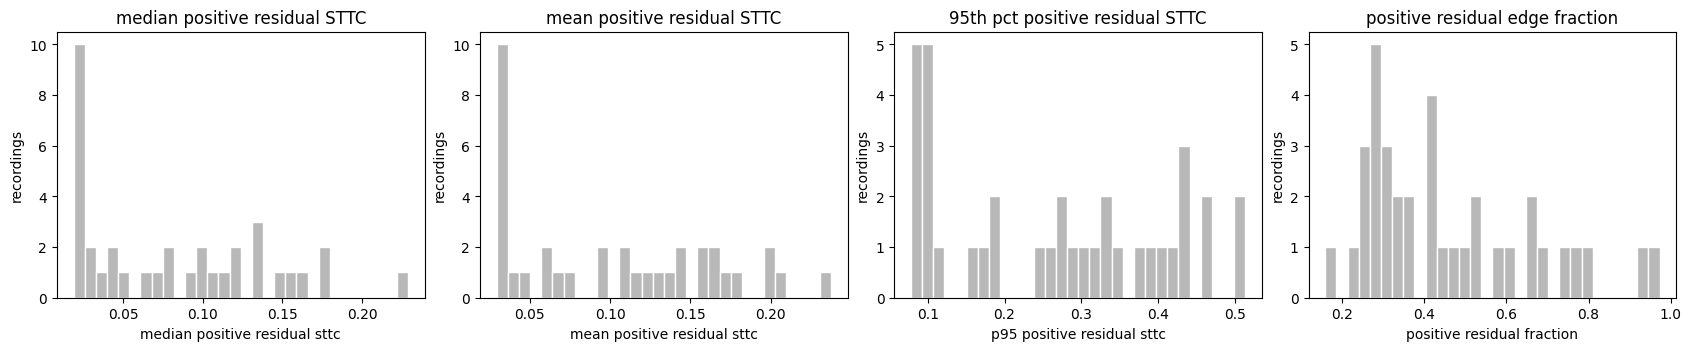

In [42]:
def draw_null_residual_global_summary(summary_df):
    if summary_df is None or summary_df.empty:
        print("No null-residual summary available.")
        return None
    metrics = [
        ("median_positive_residual_sttc", "median positive residual STTC"),
        ("mean_positive_residual_sttc", "mean positive residual STTC"),
        ("p95_positive_residual_sttc", "95th pct positive residual STTC"),
        ("positive_residual_fraction", "positive residual edge fraction"),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 3.4), constrained_layout=True)
    for ax, (metric, label) in zip(axes, metrics):
        values = summary_df[metric].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        ax.hist(values, bins=min(30, max(6, values.size)), color="0.72", edgecolor="white")
        ax.set_title(label)
        ax.set_xlabel(metric.replace("_", " "))
        ax.set_ylabel("recordings")
    return fig, axes

if null_residual_results:
    draw_null_residual_global_summary(null_residual_summary_df);
else:
    print("STTC_NULL_REPS=0 or no STTC networks; skipping null-residual summary.")


## Null-Residual Example Network Panel

This redraws one configured example network from the canonical `null_residual_results` product. The distance curve in this panel is the same corrected-adjacency distance curve used later in the well x DIV panel.


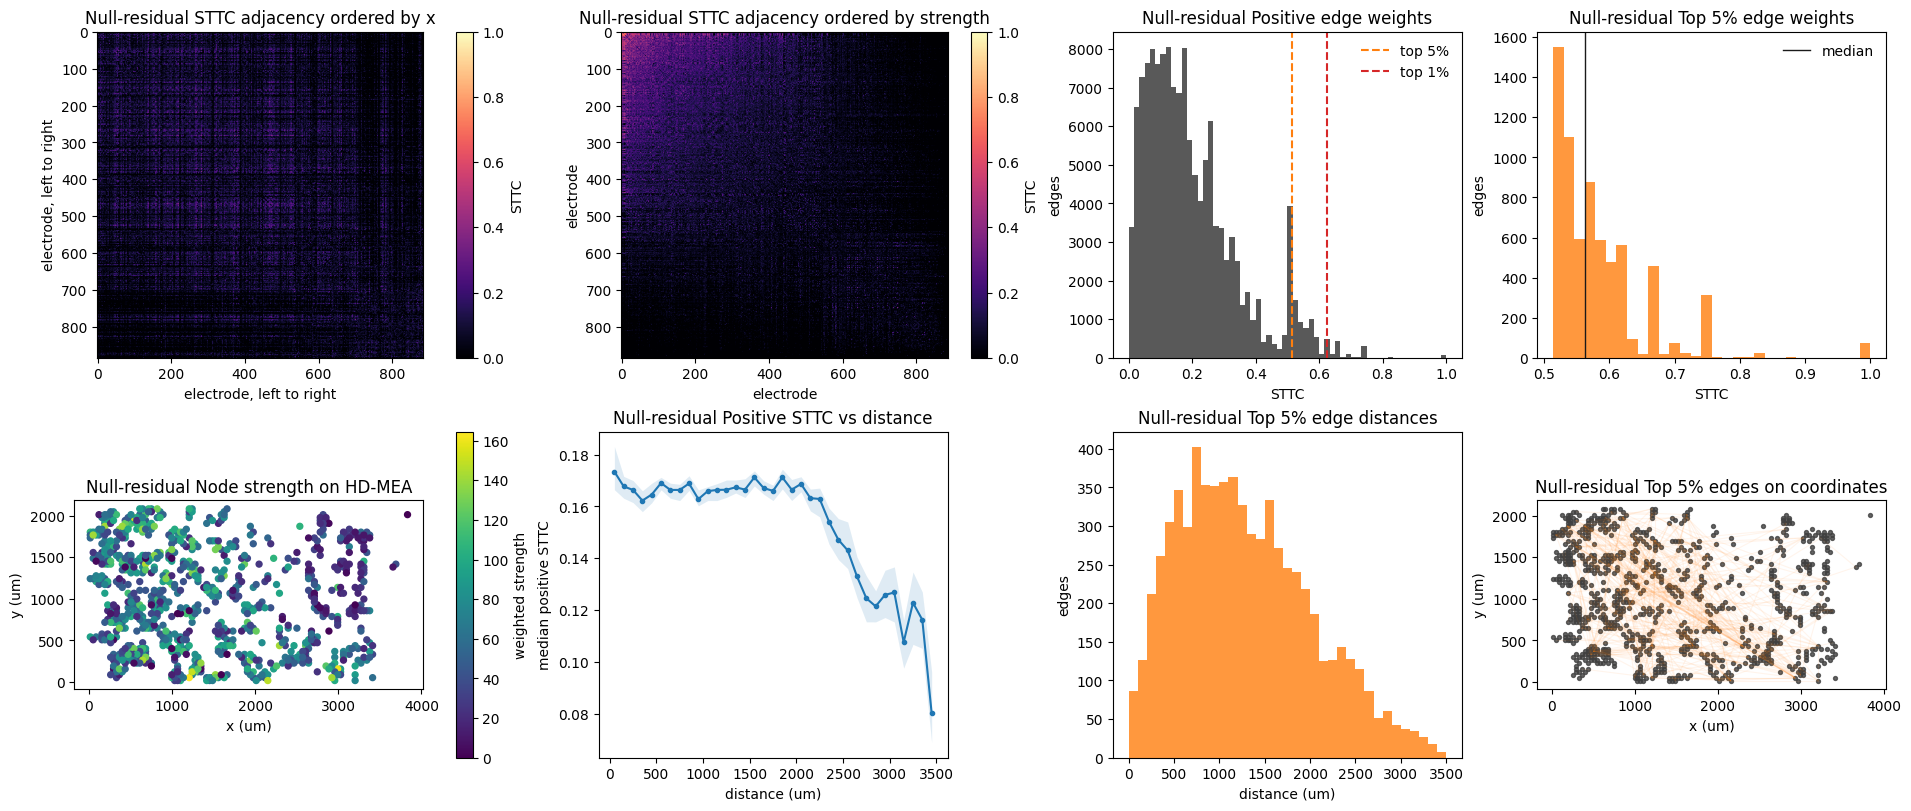

In [43]:
if null_residual_results:
    example_null_product = find_null_residual_product(well=WELL, div=DIV, fallback_first=True)
    example_sttc_result = example_null_product["result"]
    corrected_adjacency = example_null_product["corrected_adjacency"]
    draw_example_network(example_sttc_result, adjacency=corrected_adjacency, title_prefix="Null-residual ");
else:
    example_null_product = None
    corrected_adjacency = None
    print("No null-residual product available. Set STTC_NULL_REPS > 0 and run the canonical null-residual product cell.")


## Null-Residual STTC `dt` Sensitivity

For the configured example `WELL` and `DIV`, recompute/load null-corrected STTC panels at `dt = 2, 5, 10 ms`. Each plot uses the same high-activity non-burst intervals and electrode selection, but a different STTC coincidence window.


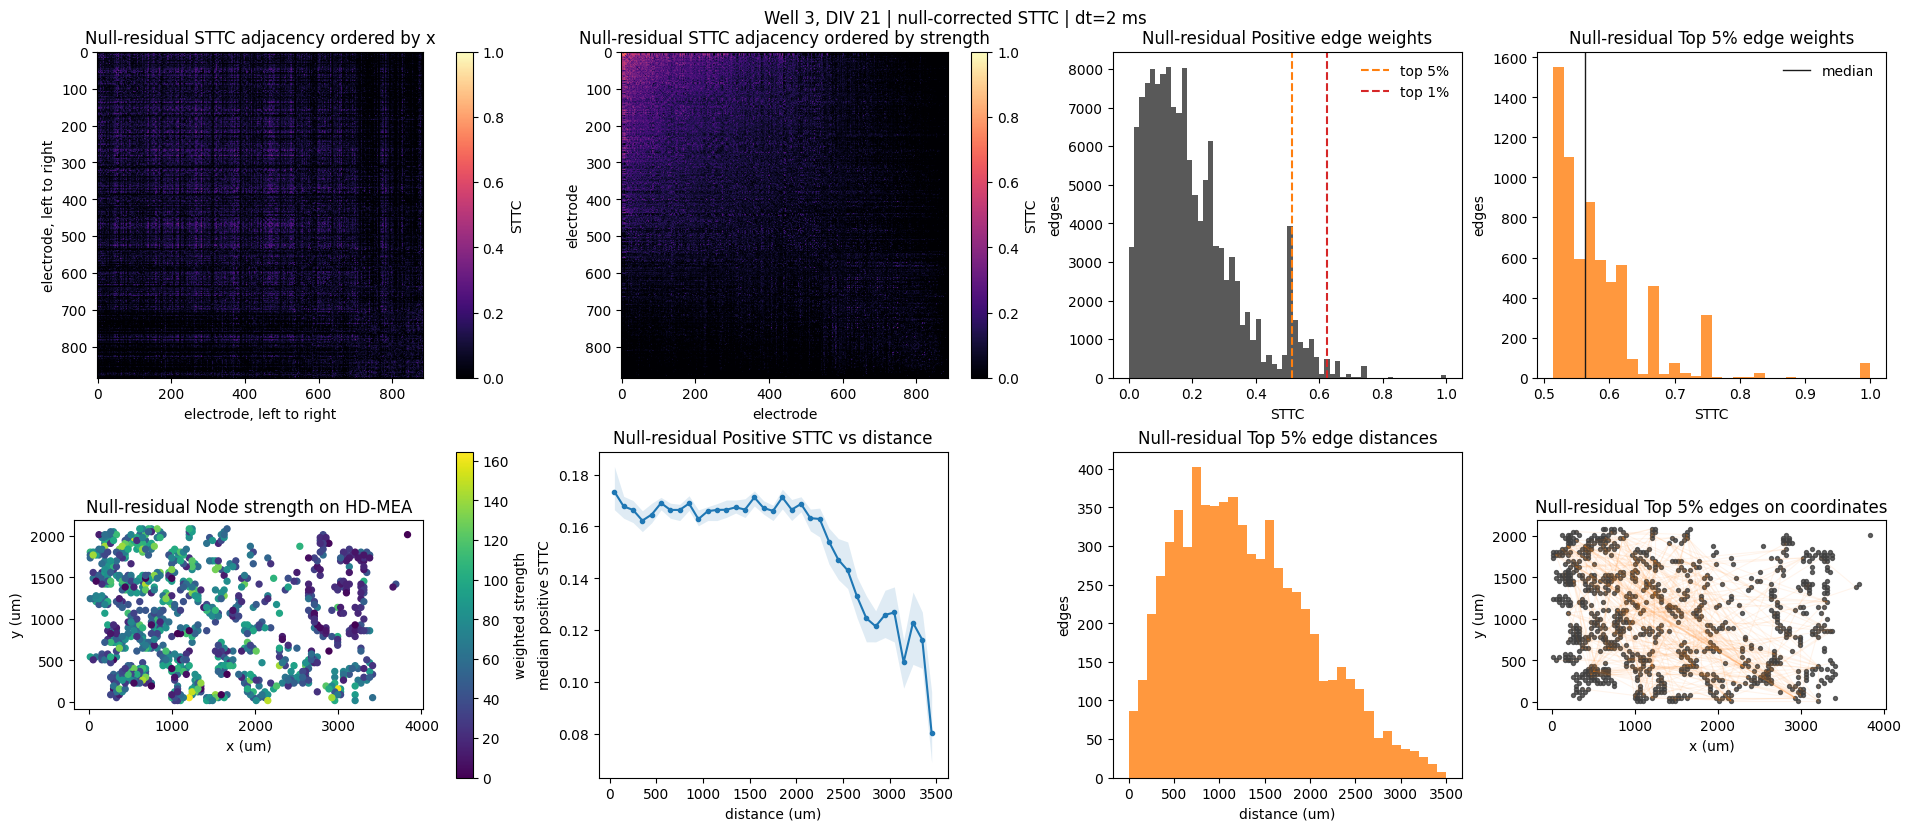

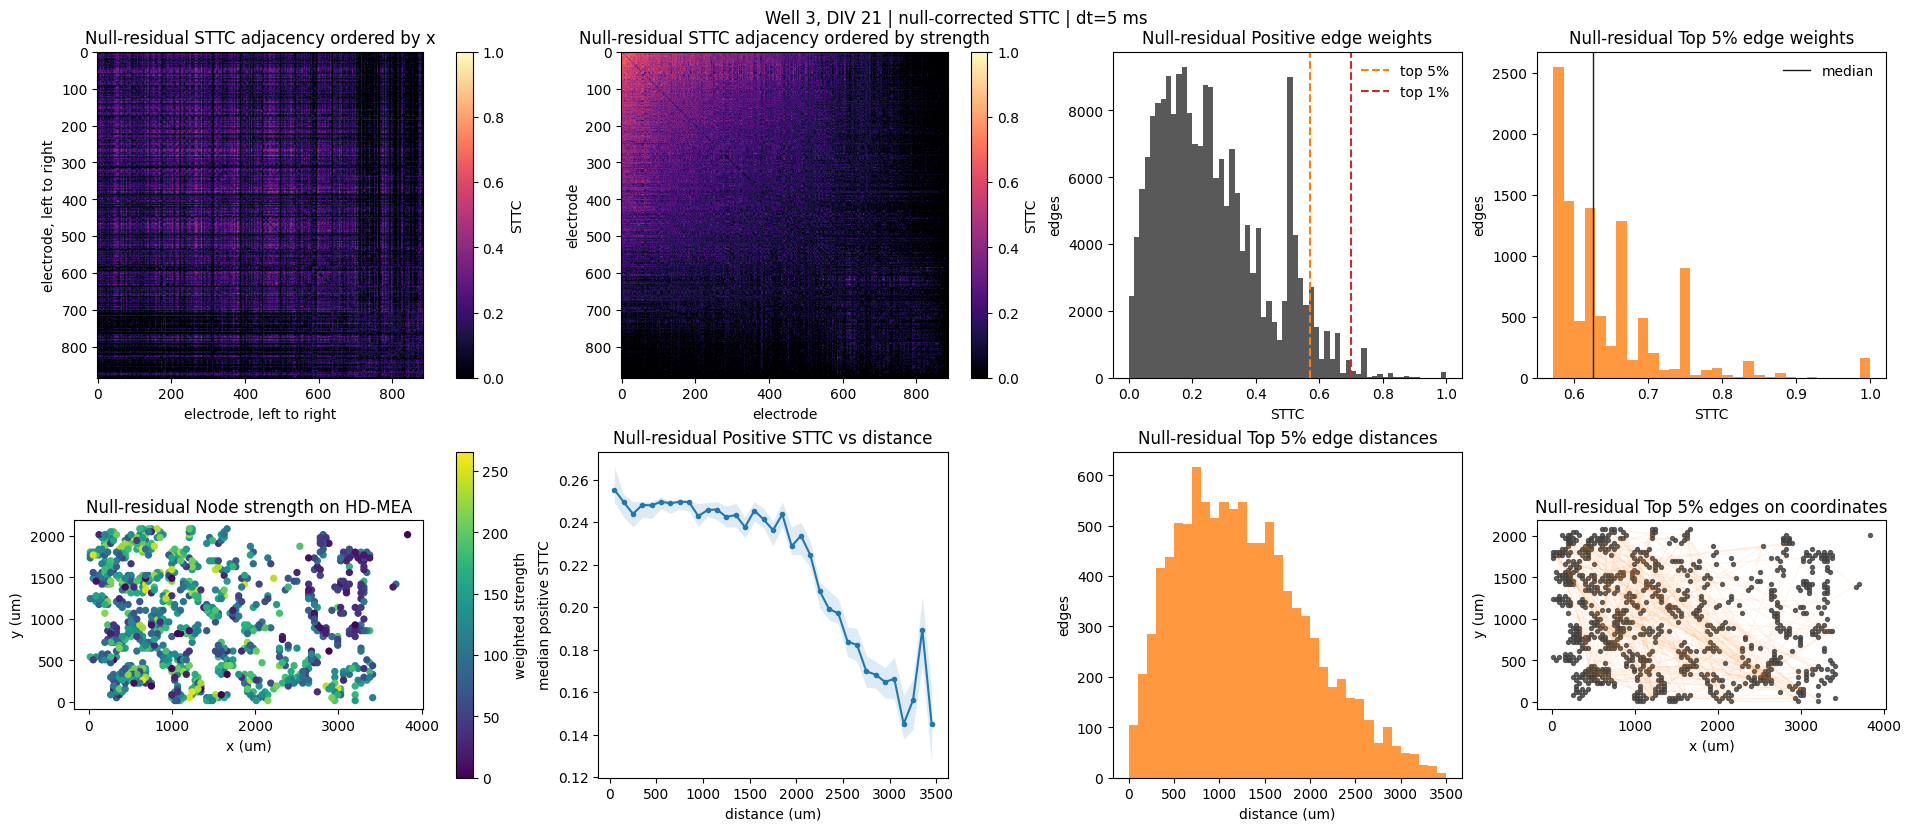

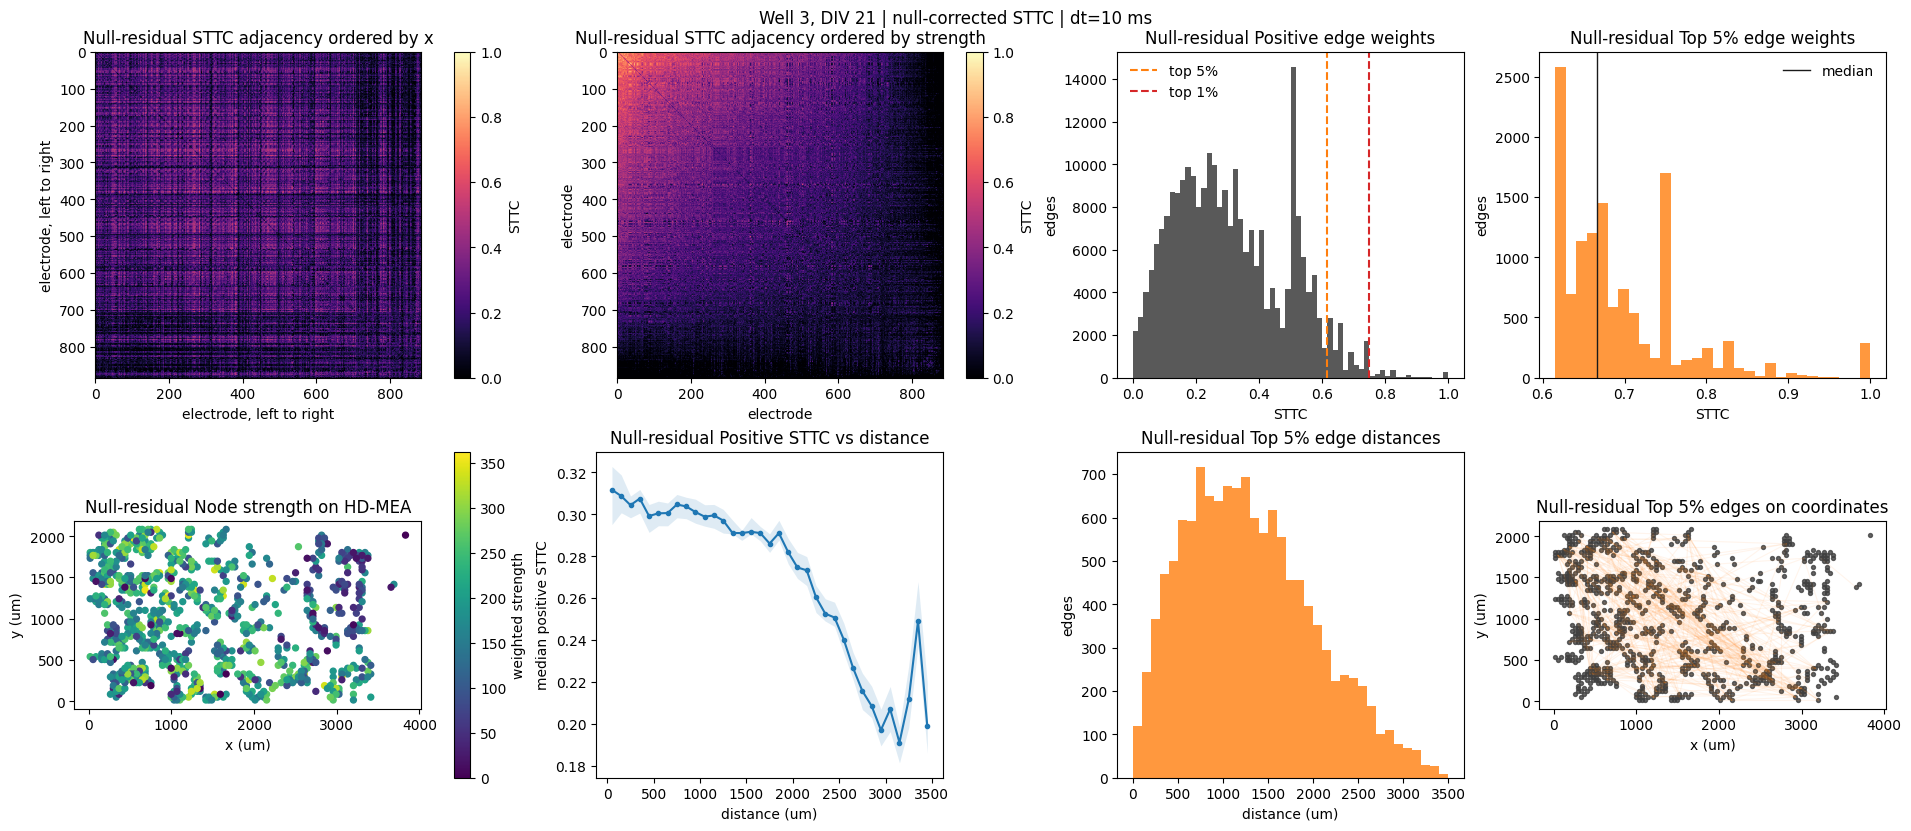

In [44]:
def find_activity_item(well=None, div=None, fallback_first=True):
    if not activity_results:
        raise ValueError("No activity results are available.")
    candidates = [item for item in activity_results if item["summary"].get("valid_for_sttc", False)]
    if well is not None:
        candidates = [item for item in candidates if int(item["spec"]["well"]) == int(well)]
    if div is not None:
        candidates = [item for item in candidates if int(item["spec"]["div"]) == int(div)]
    if candidates:
        return candidates[0]
    if fallback_first:
        fallback = next((item for item in activity_results if item["summary"].get("valid_for_sttc", False)), None)
        if fallback is not None:
            print(f"No valid activity item found for well={well}, div={div}; using first valid item instead.")
            return fallback
    raise ValueError(f"No valid activity item found for well={well}, div={div}.")


def draw_null_residual_dt_sensitivity(dt_values=STTC_DT_SENSITIVITY_MS):
    if STTC_NULL_REPS <= 0:
        print("Set STTC_NULL_REPS > 0 to draw null-corrected dt-sensitivity panels.")
        return []
    item = find_activity_item(well=WELL, div=DIV, fallback_first=True)
    spec = item["spec"]
    products = []
    for dt_ms in dt_values:
        sttc_result = compute_or_load_sttc_network(item, dt_ms=float(dt_ms))
        if sttc_result is None:
            continue
        product = compute_or_load_null_residual_product(sttc_result, n_reps=STTC_NULL_REPS)
        if product is None:
            continue
        fig, axes = draw_example_network(
            product["result"],
            adjacency=product["corrected_adjacency"],
            title_prefix="Null-residual ",
        )
        fig.suptitle(
            f"Well {int(spec['well'])}, DIV {int(spec['div'])} | null-corrected STTC | dt={float(dt_ms):g} ms",
            y=1.02,
        )
        products.append(product)
    return products


sttc_dt_sensitivity_products = draw_null_residual_dt_sensitivity()


## Aggregate Summaries

When `RUN_MODE` loads multiple wells or DIVs, these summaries compare recording-level network metrics without reloading raw spikes.

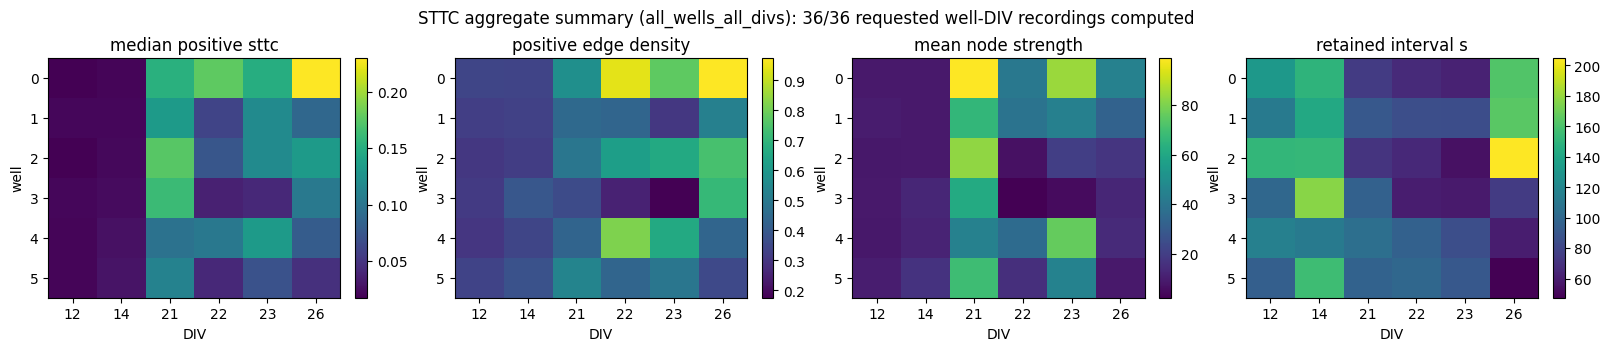

In [45]:
def draw_aggregate_summary(summary_df):
    metrics = ["median_positive_sttc", "positive_edge_density", "mean_node_strength", "retained_interval_s"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 3.4), constrained_layout=True)
    if len(metrics) == 1:
        axes = [axes]

    # Show exactly the requested matrix implied by RUN_ALL_WELLS/RUN_ALL_DIVS.
    wells = requested_wells()
    divs = requested_divs()

    for ax, metric in zip(axes, metrics):
        if summary_df.empty:
            pivot = pd.DataFrame(index=wells, columns=divs, dtype=float)
        else:
            pivot = summary_df.pivot_table(index="well", columns="div", values=metric, aggfunc="median")
            pivot = pivot.reindex(index=wells, columns=divs)
        values = pivot.to_numpy(dtype=float)
        masked = np.ma.masked_invalid(values)
        cmap = plt.get_cmap("viridis").copy()
        cmap.set_bad("0.90")
        im = ax.imshow(masked, aspect="auto", cmap=cmap)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("DIV")
        ax.set_ylabel("well")
        ax.set_xticks(np.arange(len(divs)))
        ax.set_xticklabels([str(c) for c in divs])
        ax.set_yticks(np.arange(len(wells)))
        ax.set_yticklabels([str(i) for i in wells])
        for yi in range(len(wells)):
            for xi in range(len(divs)):
                if not np.isfinite(values[yi, xi]):
                    ax.text(xi, yi, "missing", ha="center", va="center", color="0.45", fontsize=7)
        fig.colorbar(im, ax=ax)
    computed_pairs = set()
    if not summary_df.empty:
        computed_pairs = set(zip(summary_df["well"].astype(int), summary_df["div"].astype(int)))
    requested_pairs = {(int(w), int(d)) for w in wells for d in divs}
    missing_n = len(requested_pairs - computed_pairs)
    fig.suptitle(
        f"STTC aggregate summary ({RUN_MODE}): {len(computed_pairs & requested_pairs)}/{len(requested_pairs)} requested well-DIV recordings computed"
        + (f"; {missing_n} missing/skipped" if missing_n else "")
    )
    return fig, axes

draw_aggregate_summary(sttc_summary_df);


## Null-Residual Distance and Matrix Views

The following panels read from the canonical `null_residual_results` computed above.


## Null-Residual Positive STTC Over Distance

Distance-resolved null-residual STTC curves for every requested well-DIV recording. These curves are derived from the canonical corrected adjacencies in `null_residual_results`, not sampled-pair approximations and not separate recomputations.


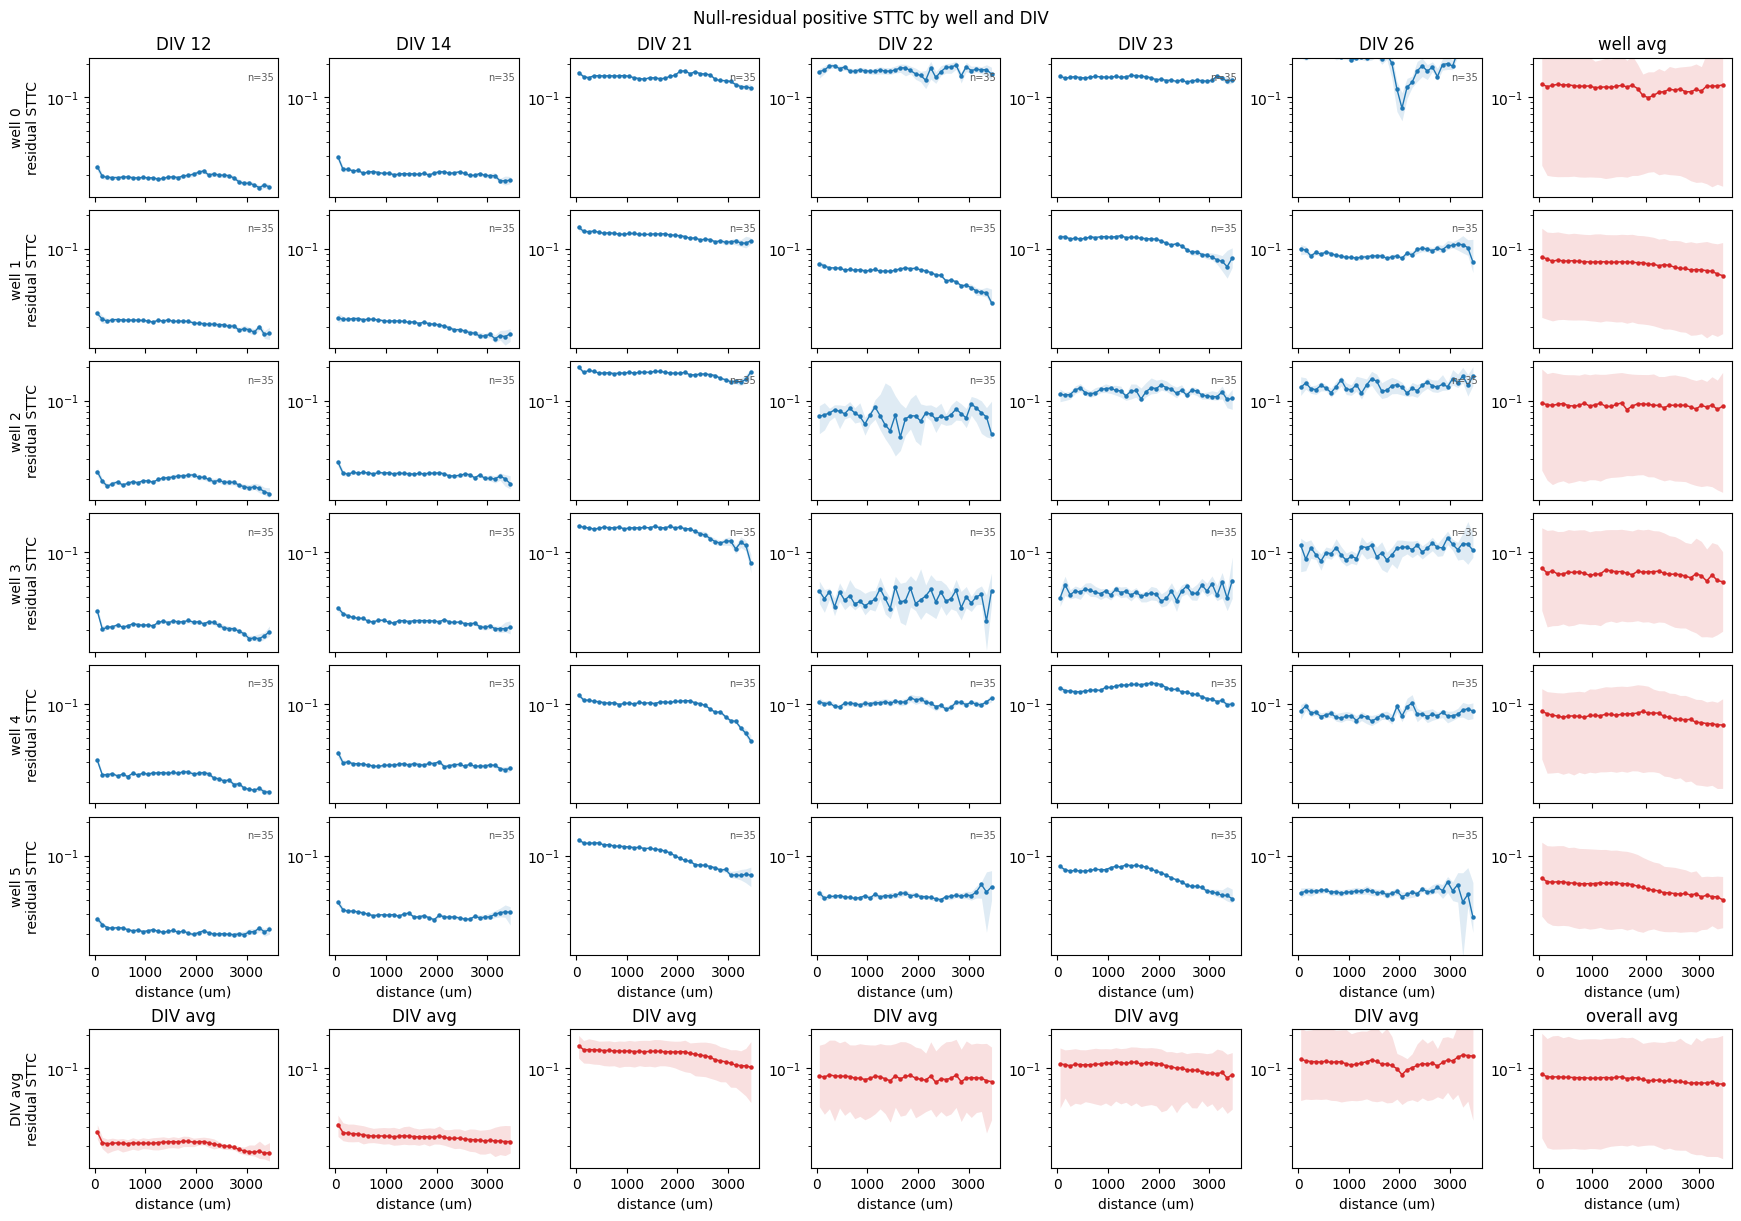

In [46]:
def null_residual_distance_tables(products):
    parts = []
    for product in products:
        curve = product["distance_curve_df"].copy()
        if curve.empty:
            continue
        curve["curve_source"] = product["source"]
        curve["n_null_reps"] = int(product["summary"].get("n_null_reps", 0))
        if not {"ci_low", "ci_high"}.issubset(curve.columns):
            curve["ci_low"] = curve["median_positive_residual_sttc"]
            curve["ci_high"] = curve["median_positive_residual_sttc"]
        parts.append(curve)
    summary_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    # Keep a reps-shaped table for shared averaging code. Exact curves have one canonical row per distance bin.
    reps_df = summary_df.copy()
    if not reps_df.empty:
        reps_df.insert(0, "rep", 0)
    return reps_df, summary_df


def summarize_distance_average_curve(reps_df, *, well=None, div=None):
    if reps_df is None or reps_df.empty:
        return pd.DataFrame()
    group = reps_df.copy()
    if well is not None:
        group = group[group["well"] == int(well)]
    if div is not None:
        group = group[group["div"] == int(div)]
    if group.empty:
        return pd.DataFrame()
    rows = []
    for distance_um, distance_group in group.groupby("distance_um"):
        values = distance_group["median_positive_residual_sttc"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        rows.append({
            "distance_um": float(distance_um),
            "mean_residual_sttc": float(np.mean(values)) if values.size else np.nan,
            "ci_low": float(np.quantile(values, 0.025)) if values.size > 1 else (float(values[0]) if values.size else np.nan),
            "ci_high": float(np.quantile(values, 0.975)) if values.size > 1 else (float(values[0]) if values.size else np.nan),
            "n_recordings": int(values.size),
        })
    return pd.DataFrame(rows).sort_values("distance_um")


def draw_curve_with_ci(ax, curve_df, *, color="tab:blue", title=None):
    if curve_df is None or curve_df.empty:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
        return
    x = curve_df["distance_um"].to_numpy(dtype=float)
    y = curve_df["mean_residual_sttc"].to_numpy(dtype=float)
    y = np.where(y > 0, y, np.nan)
    lo = curve_df["ci_low"].to_numpy(dtype=float)
    lo = np.where(lo > 0, lo, np.nan)
    hi = curve_df["ci_high"].to_numpy(dtype=float)
    hi = np.where(hi > 0, hi, np.nan)
    if np.any(np.isfinite(lo)) and np.any(np.isfinite(hi)):
        ax.fill_between(x, lo, hi, color=color, alpha=0.14, lw=0)
    ax.plot(x, y, marker="o", ms=2.2, lw=1.1, color=color)
    if title:
        ax.set_title(title)


def draw_null_residual_distance_grid(summary_df, reps_df=None):
    wells = requested_wells()
    divs = requested_divs()
    fig = plt.figure(
        figsize=(2.45 * len(divs) + 2.6, 1.65 * len(wells) + 2.2),
        constrained_layout=True,
    )
    gs = fig.add_gridspec(
        len(wells) + 1,
        len(divs) + 1,
        width_ratios=[1.0] * len(divs) + [1.05],
        height_ratios=[1.0] * len(wells) + [1.0],
    )
    axes = np.empty((len(wells), len(divs)), dtype=object)
    finite_values = summary_df["median_positive_residual_sttc"].to_numpy(dtype=float) if not summary_df.empty else np.array([])
    finite_values = finite_values[np.isfinite(finite_values) & (finite_values > 0)]
    if finite_values.size:
        y_min = max(np.finfo(float).tiny, float(np.nanquantile(finite_values, 0.02)) * 0.75)
        y_max = max(y_min * 10.0, float(np.nanquantile(finite_values, 0.98)) * 1.15)
    else:
        y_min, y_max = 1e-6, 1e-2

    for row_idx, well in enumerate(wells):
        for col_idx, div in enumerate(divs):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            axes[row_idx, col_idx] = ax
            group = summary_df[(summary_df["well"] == int(well)) & (summary_df["div"] == int(div))].sort_values("distance_um")
            if group.empty:
                ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", color="0.55")
            else:
                x = group["distance_um"].to_numpy(dtype=float)
                y = group["median_positive_residual_sttc"].to_numpy(dtype=float)
                y = np.where(y > 0, y, np.nan)
                if {"ci_low", "ci_high"}.issubset(group.columns):
                    lo = group["ci_low"].to_numpy(dtype=float)
                    lo = np.where(lo > 0, lo, np.nan)
                    hi = group["ci_high"].to_numpy(dtype=float)
                    hi = np.where(hi > 0, hi, np.nan)
                    if np.any(np.isfinite(lo)) and np.any(np.isfinite(hi)):
                        ax.fill_between(x, lo, hi, color="tab:blue", alpha=0.14, lw=0)
                ax.plot(x, y, marker="o", ms=2.2, lw=1.0, color="tab:blue")
                ax.text(0.98, 0.90, f"n={int(np.sum(np.isfinite(y)))}", transform=ax.transAxes, ha="right", va="top", fontsize=7, color="0.35")
            ax.set_yscale("log")
            ax.set_ylim(y_min, y_max)
            if row_idx == 0:
                ax.set_title(f"DIV {div}")
            if col_idx == 0:
                ax.set_ylabel(f"well {well}\nresidual STTC")
            if row_idx == len(wells) - 1:
                ax.set_xlabel("distance (um)")
            else:
                ax.tick_params(labelbottom=False)

        ax_row = fig.add_subplot(gs[row_idx, len(divs)])
        draw_curve_with_ci(ax_row, summarize_distance_average_curve(reps_df, well=well), color="tab:red", title="well avg" if row_idx == 0 else None)
        ax_row.set_yscale("log")
        ax_row.set_ylim(y_min, y_max)
        if row_idx == len(wells) - 1:
            ax_row.set_xlabel("distance (um)")
        else:
            ax_row.tick_params(labelbottom=False)

    for col_idx, div in enumerate(divs):
        ax_col = fig.add_subplot(gs[len(wells), col_idx])
        draw_curve_with_ci(ax_col, summarize_distance_average_curve(reps_df, div=div), color="tab:red", title="DIV avg")
        ax_col.set_yscale("log")
        ax_col.set_ylim(y_min, y_max)
        ax_col.set_xlabel("distance (um)")
        if col_idx == 0:
            ax_col.set_ylabel("DIV avg\nresidual STTC")

    ax_overall = fig.add_subplot(gs[len(wells), len(divs)])
    draw_curve_with_ci(ax_overall, summarize_distance_average_curve(reps_df), color="tab:red", title="overall avg")
    ax_overall.set_yscale("log")
    ax_overall.set_ylim(y_min, y_max)
    ax_overall.set_xlabel("distance (um)")
    fig.suptitle("Null-residual positive STTC by well and DIV")
    return fig, axes


null_residual_distance_reps_df, null_residual_distance_summary_df = null_residual_distance_tables(null_residual_results)
if not null_residual_distance_summary_df.empty:
    draw_null_residual_distance_grid(null_residual_distance_summary_df, null_residual_distance_reps_df);
else:
    print("No null-residual distance summary available. Compute STTC results first.")


## All-Well/All-DIV Null-Residual Positive STTC Panel

This panel summarizes the same canonical null-residual products as scalar recording-level medians. The matrix and margins are derived from `null_residual_summary_df`; no extra null computations are run here.


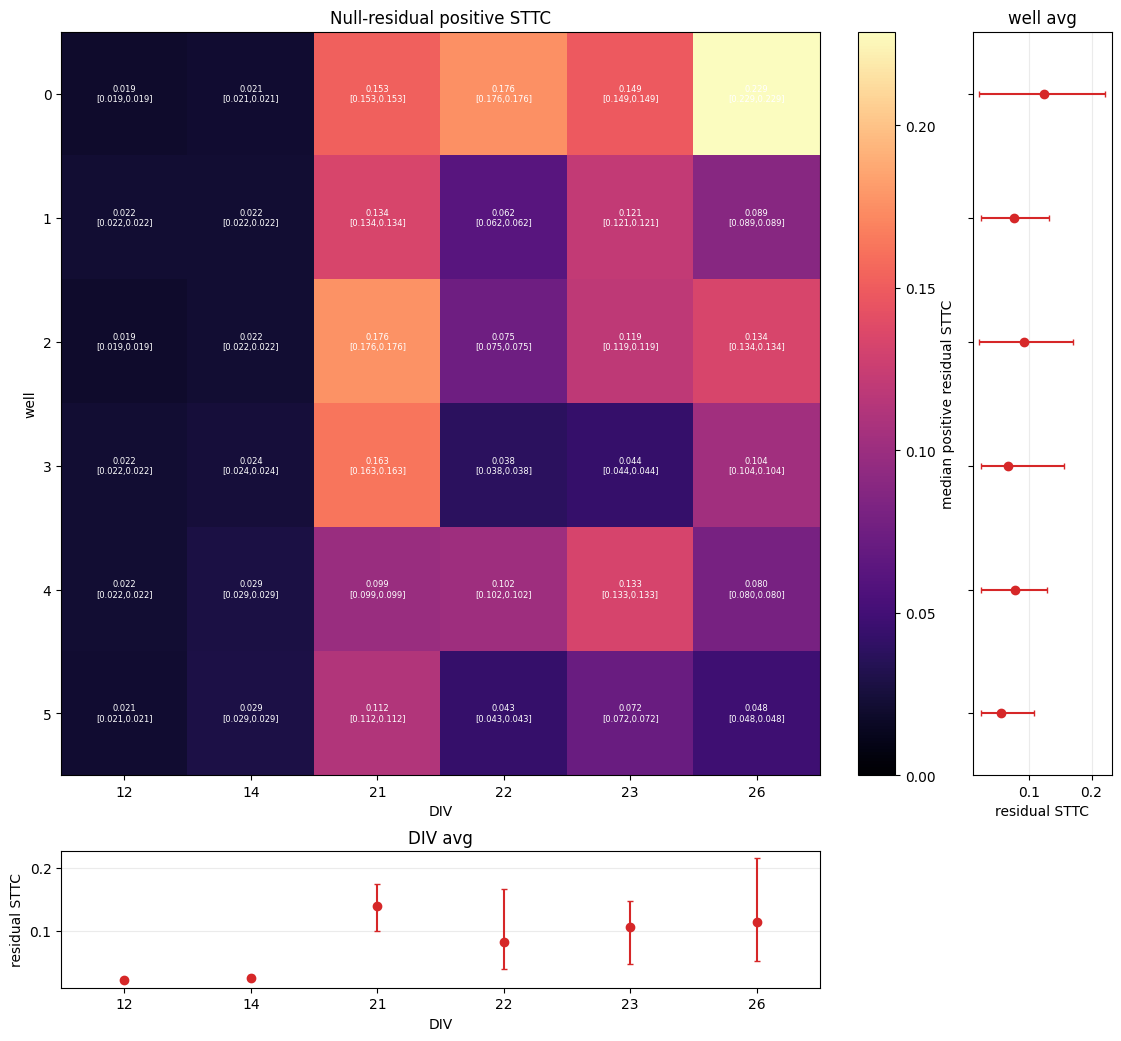

In [47]:
def _mean_ci_from_summary(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    center = float(np.mean(values))
    if values.size == 1:
        return center, center, center
    return center, float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))


def draw_null_residual_well_div_panel(summary_df):
    wells = requested_wells()
    divs = requested_divs()
    metric = "median_positive_residual_sttc"
    value = np.full((len(wells), len(divs)), np.nan, dtype=float)
    lo = np.full_like(value, np.nan)
    hi = np.full_like(value, np.nan)
    for r, well in enumerate(wells):
        for c, div in enumerate(divs):
            group = summary_df[(summary_df["well"] == int(well)) & (summary_df["div"] == int(div))]
            center, low, high = _mean_ci_from_summary(group[metric].to_numpy(dtype=float) if not group.empty else [])
            value[r, c] = center
            lo[r, c] = low
            hi[r, c] = high

    finite = value[np.isfinite(value)]
    vmin = 0.0 if finite.size else 0.0
    vmax = float(np.nanmax(finite)) if finite.size else 1.0
    fig = plt.figure(figsize=(1.35 * len(divs) + 3.0, 1.25 * len(wells) + 2.8), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, width_ratios=[len(divs), 1.1], height_ratios=[len(wells), 1.1])
    ax = fig.add_subplot(gs[0, 0])
    im = ax.imshow(value, cmap="magma", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(np.arange(len(divs)), labels=divs)
    ax.set_yticks(np.arange(len(wells)), labels=wells)
    ax.set_xlabel("DIV")
    ax.set_ylabel("well")
    ax.set_title("Null-residual positive STTC")
    for r in range(len(wells)):
        for c in range(len(divs)):
            if np.isfinite(value[r, c]):
                ax.text(c, r, f"{value[r, c]:.3f}\n[{lo[r, c]:.3f},{hi[r, c]:.3f}]", ha="center", va="center", color="white", fontsize=6)
            else:
                ax.text(c, r, "missing", ha="center", va="center", color="0.75", fontsize=7)
    fig.colorbar(im, ax=ax, label="median positive residual STTC")

    ax_row = fig.add_subplot(gs[0, 1], sharey=ax)
    row_centers = []
    for r, well in enumerate(wells):
        center, low, high = _mean_ci_from_summary(summary_df.loc[summary_df["well"] == int(well), metric].to_numpy(dtype=float))
        row_centers.append(center)
        if np.isfinite(center):
            ax_row.errorbar(center, r, xerr=[[center - low], [high - center]], fmt="o", color="tab:red", capsize=2)
    ax_row.set_title("well avg")
    ax_row.set_xlabel("residual STTC")
    ax_row.tick_params(labelleft=False)
    ax_row.grid(axis="x", alpha=0.25)

    ax_col = fig.add_subplot(gs[1, 0], sharex=ax)
    for c, div in enumerate(divs):
        center, low, high = _mean_ci_from_summary(summary_df.loc[summary_df["div"] == int(div), metric].to_numpy(dtype=float))
        if np.isfinite(center):
            ax_col.errorbar(c, center, yerr=[[center - low], [high - center]], fmt="o", color="tab:red", capsize=2)
    ax_col.set_title("DIV avg")
    ax_col.set_ylabel("residual STTC")
    ax_col.set_xlabel("DIV")
    ax_col.grid(axis="y", alpha=0.25)
    return fig, {"matrix": ax, "well_avg": ax_row, "div_avg": ax_col}


if null_residual_results:
    draw_null_residual_well_div_panel(null_residual_summary_df);
else:
    print("No null-residual scalar summary available.")


In [48]:
# Save thresholded edge tables and distance summaries for downstream graph analysis.
edge_output_rows = []
distance_output_rows = []
for result in sttc_results:
    spec = result["item"]["spec"]
    for fraction, edge_df in result["edge_tables"].items():
        if edge_df is None or edge_df.empty:
            continue
        edge_df = edge_df.copy()
        edge_df.insert(0, "top_fraction", fraction)
        edge_df.insert(0, "recording_id", spec["recording_id"])
        edge_df.insert(0, "div", spec["div"])
        edge_df.insert(0, "well", spec["well"])
        edge_output_rows.append(edge_df)
    distance_df = binned_sttc_by_distance(result)
    if not distance_df.empty:
        distance_df.insert(0, "recording_id", spec["recording_id"])
        distance_df.insert(0, "div", spec["div"])
        distance_df.insert(0, "well", spec["well"])
        distance_output_rows.append(distance_df)

edge_summary_df = pd.concat(edge_output_rows, ignore_index=True) if edge_output_rows else pd.DataFrame()
distance_summary_df = pd.concat(distance_output_rows, ignore_index=True) if distance_output_rows else pd.DataFrame()

edge_summary_df.to_csv(OUTPUT_DIR / "sttc_thresholded_edges.csv", index=False)
distance_summary_df.to_csv(OUTPUT_DIR / "sttc_distance_summary.csv", index=False)
interval_summary.to_csv(OUTPUT_DIR / "sttc_interval_summary.csv", index=False)
recording_summary.to_csv(OUTPUT_DIR / "sttc_activity_state_summary.csv", index=False)

print(f"Wrote outputs to {OUTPUT_DIR}")
print(f"recordings: {len(sttc_summary_df)}, edge rows: {len(edge_summary_df)}, distance rows: {len(distance_summary_df)}")

Wrote outputs to /Users/danielrebbin/Documents/GitHub/ephax/outputs/sttc_networks
recordings: 36, edge rows: 657618, distance rows: 1260
